In [41]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import dendrogram
!pip install adjustText
from adjustText import adjust_text
import math
from IPython.display import display

In [42]:
# 0. copie et diagnostic rapide
df = pd.read_csv('/content/drive/MyDrive/df_EDA_P11.csv')
print(df.shape)
print(df.dtypes.value_counts())
print(df.isna().sum().sort_values(ascending=False).head(10))

(169, 13)
float64    10
object      2
int64       1
Name: count, dtype: int64
_orig_index                                               0
Zone                                                      0
Disponibilité alimentaire en quantité (kg/personne/an)    0
Disponibilité intérieure                                  0
Importations - Quantité                                   0
Exportations - Quantité                                   0
Production                                                0
Population                                                0
Pib_par_habitant                                          0
Net_trade                                                 0
dtype: int64


In [43]:
# 1. sélectionner colonnes numériques (après remplissage)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
Xnum = df[num_cols].copy()

# 2. standardiser (obligatoire avant ACP/k-means)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(Xnum), index=Xnum.index, columns=num_cols)

# 3. PCA complète
pca = PCA(n_components=min(X_scaled.shape[0], X_scaled.shape[1]), svd_solver='auto', random_state=0)
X_pca = pca.fit_transform(X_scaled)

In [44]:
df

,_orig_index,Zone,Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Production,Population,Pib_par_habitant,Net_trade,Auto_sufficiency,Production_per_capita,Zone_clean
0,0,Afghanistan,1.53,57.0,29.0,0.0,28.0,36296.113,533.0,0.0,0.491228,0.000771,Afghanistan
1,1,Afrique du Sud,35.69,2118.0,514.0,63.0,1667.0,57009.756,6613.0,451.0,0.787063,0.029241,Afrique du Sud
2,2,Albanie,16.36,47.0,38.0,0.0,13.0,2884.169,4492.0,38.0,0.276596,0.004507,Albanie
3,3,Algérie,6.38,277.0,2.0,0.0,275.0,41389.189,4080.0,2.0,0.992780,0.006644,Algérie
4,4,Allemagne,19.47,1739.0,842.0,646.0,1514.0,82658.409,45282.0,196.0,0.870615,0.018316,Allemagne
...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,167,Émirats arabes unis,43.47,412.0,433.0,94.0,48.0,9487.203,42290.0,339.0,0.116505,0.005059,Émirats arabes unis
165,168,Équateur,19.31,341.0,0.0,0.0,340.0,16785.361,6233.0,0.0,0.997067,0.020256,Équateur
166,169,États-Unis d'Amérique,55.68,18266.0,123.0,3692.0,21914.0,325084.756,59036.0,-3569.0,1.199715,0.067410,États-Unis d'Amérique
167,170,Éthiopie,0.13,14.0,1.0,0.0,14.0,106399.924,700.0,0.0,1.000000,0.000132,Éthiopie


DIAGRAMME EBOULIS DES VALEURS PROPRES

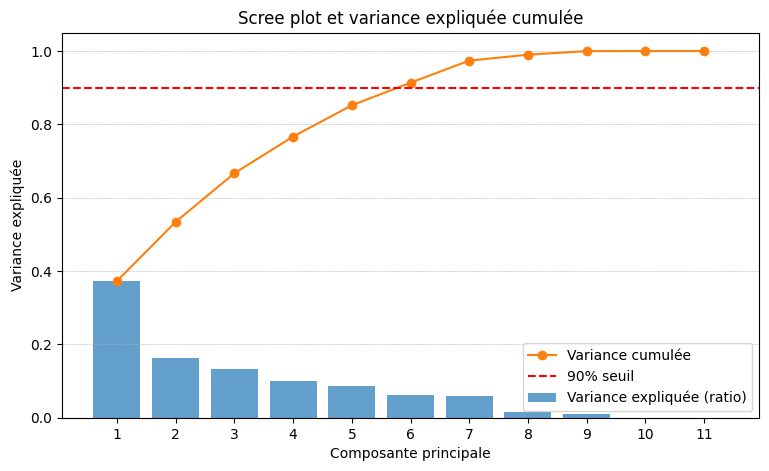

,PC,explained_var_ratio,cum_explained_var,eigenvalue
0,1,0.372704,0.372704,4.124146
1,2,0.161539,0.534243,1.787508
2,3,0.132470,0.666713,1.465847
3,4,0.100101,0.766814,1.107663
4,5,0.085233,0.852047,0.943144
5,6,0.061681,0.913728,0.682524
6,7,0.060129,0.973857,0.665355
7,8,0.016305,0.990162,0.180423
8,9,0.009680,0.999841,0.107110
9,10,0.000121,0.999962,0.001341


In [45]:
# explained_var déjà calculé : pca.explained_variance_ratio_
explained_var = pca.explained_variance_ratio_
eigenvalues = pca.explained_variance_  # autovalues
pcs = np.arange(1, len(explained_var) + 1)

evr_df = pd.DataFrame({
    'PC': pcs,
    'explained_var_ratio': explained_var,
    'cum_explained_var': explained_var.cumsum(),
    'eigenvalue': eigenvalues
})
## DIAGRAMME EBOULIS
# Scree plot (bar) + ligne variance cumulée
plt.figure(figsize=(9,5))
plt.bar(pcs, explained_var, color='C0', alpha=0.7, label='Variance expliquée (ratio)')
plt.plot(pcs, evr_df['cum_explained_var'], color='C1', marker='o', label='Variance cumulée')
plt.axhline(0.90, color='red', linestyle='--', label='90% seuil')
plt.xticks(pcs)
plt.xlabel('Composante principale')
plt.ylabel('Variance expliquée')
plt.title('Scree plot et variance expliquée cumulée')
plt.legend()
plt.grid(axis='y', linestyle='--', linewidth=0.4)
plt.show()

# Afficher dataframe valeurs propres
evr_df.to_csv('pca_explained_variance.csv', index=False)
evr_df.head(10)


CERCLE DES CORRELATIONS

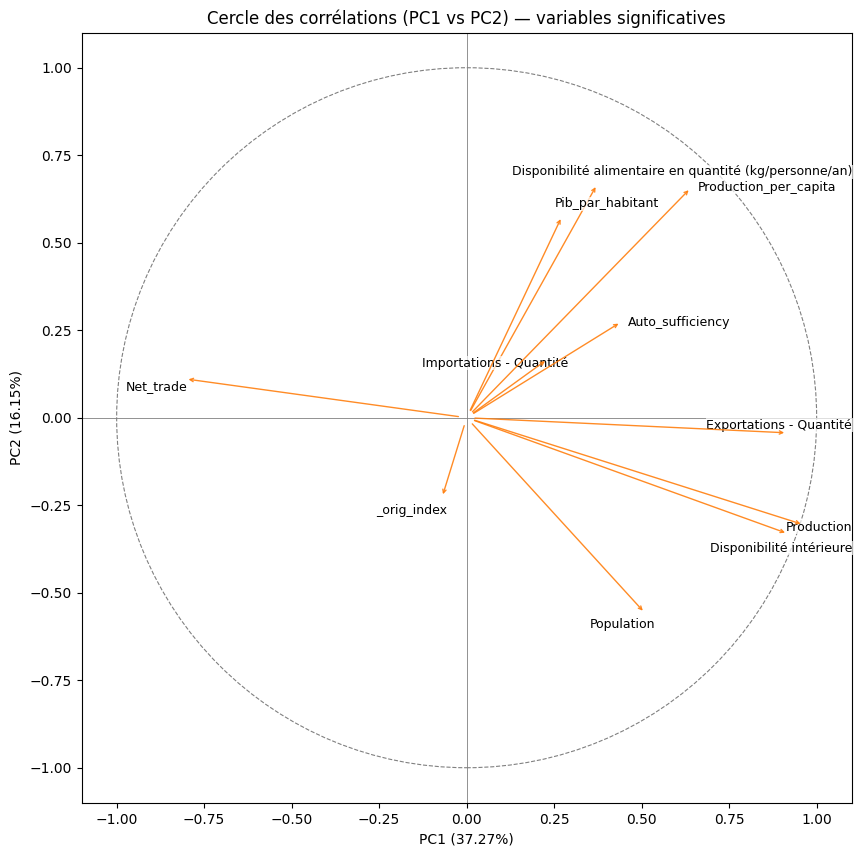

Cercle des corrélations tracé — variables affichées: 11


In [46]:
# Calculer les loadings si nécessaire puis trace le cercle des corrélations.

# Paramètres (à ajuster si besoin)
figsize = (10,10)
label_font = 9
loading_thresh = 0.20   # seuil minimal pour afficher une variable
arrow_alpha = 0.9
head_width = 6          # mutation_scale pour annotate
shrinkA = 6
shrinkB = 6

# Vérifications préalables
if 'pca' not in globals():
    raise NameError("Objet 'pca' introuvable. Exécutez la cellule PCA avant.")
if 'X_scaled' not in globals():
    raise NameError("DataFrame 'X_scaled' introuvable. Exécutez la standardisation avant le PCA.")
if pca.n_components_ < 2:
    raise ValueError("PCA contient moins de 2 composantes ; impossible de tracer PC1 vs PC2.")

# Calcul des loadings (corrélations variables <-> composantes) si absent
if 'loadings' not in globals():
    eigenvals = pca.explained_variance_
    components = pca.components_  # shape (n_components, n_features)
    loadings_arr = components.T * np.sqrt(eigenvals[np.newaxis, :])
    var_names = X_scaled.columns.tolist() if hasattr(X_scaled, "columns") else [f'var{i}' for i in range(loadings_arr.shape[0])]
    pc_names = [f'PC{i+1}' for i in range(loadings_arr.shape[1])]
    loadings = pd.DataFrame(loadings_arr, index=var_names, columns=pc_names)

# Extraire PC1 et PC2 en corrélations (normaliser pour rester dans [-1,1])
# Ici on convertit les loadings en coefficients de corrélation en divisant par racine(n_obs-1) si besoin,
# mais la formule ci‑dessous produit les valeurs usuelles employées pour le cercle de corrélations.
x_load = loadings['PC1']
y_load = loadings['PC2']

# Sélection des variables à afficher (par seuil absolu ou par top N)
vars_to_show = [v for v in loadings.index if (abs(x_load.loc[v]) >= loading_thresh) or (abs(y_load.loc[v]) >= loading_thresh)]
# Si trop peu de variables sélectionnées, afficher top 20 par contribution combinée
if len(vars_to_show) < 6:
    loadings['norm12'] = np.sqrt(loadings['PC1']**2 + loadings['PC2']**2)
    vars_to_show = loadings.sort_values('norm12', ascending=False).head(20).index.tolist()

# Tracé
fig, ax = plt.subplots(figsize=figsize)

# Cercle unité
circle = plt.Circle((0,0), 1, color='grey', fill=False, linestyle='--', linewidth=0.8)
ax.add_patch(circle)

# Points origine (pour référence)
ax.scatter(0, 0, alpha=0)  # placeholder

texts = []
annotations = []

for var in vars_to_show:
    lx = x_load.loc[var]
    ly = y_load.loc[var]
    lx_text = lx * 1.05
    ly_text = ly * 1.05
    # texte
    t = ax.text(lx_text, ly_text, var, fontsize=label_font, ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.4))
    texts.append(t)
    # flèche depuis l'origine
    ann = ax.annotate(
        '', xy=(lx_text, ly_text), xytext=(0,0),
        arrowprops=dict(arrowstyle='->', color='C1', alpha=arrow_alpha,
                        shrinkA=shrinkA, shrinkB=shrinkB, mutation_scale=head_width, lw=1)
    )
    annotations.append(ann)

# Ajuster les textes pour éviter chevauchement (ne déplace que les textes)
adjust_text(texts, only_move={'points':'y','texts':'y'}, expand_text=(1.05,1.2), arrowprops=None)

# Axes et décoration
ax.axhline(0, color='grey', linewidth=0.6)
ax.axvline(0, color='grey', linewidth=0.6)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=10)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=10)
ax.set_title('Cercle des corrélations (PC1 vs PC2) — variables significatives', fontsize=12)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal', 'box')
plt.grid(False)
plt.show()

# Sortie explicite (nommage pour usage ultérieur)
print("Cercle des corrélations tracé — variables affichées:", len(vars_to_show))


PROJECTION DES GRAPHIQUES

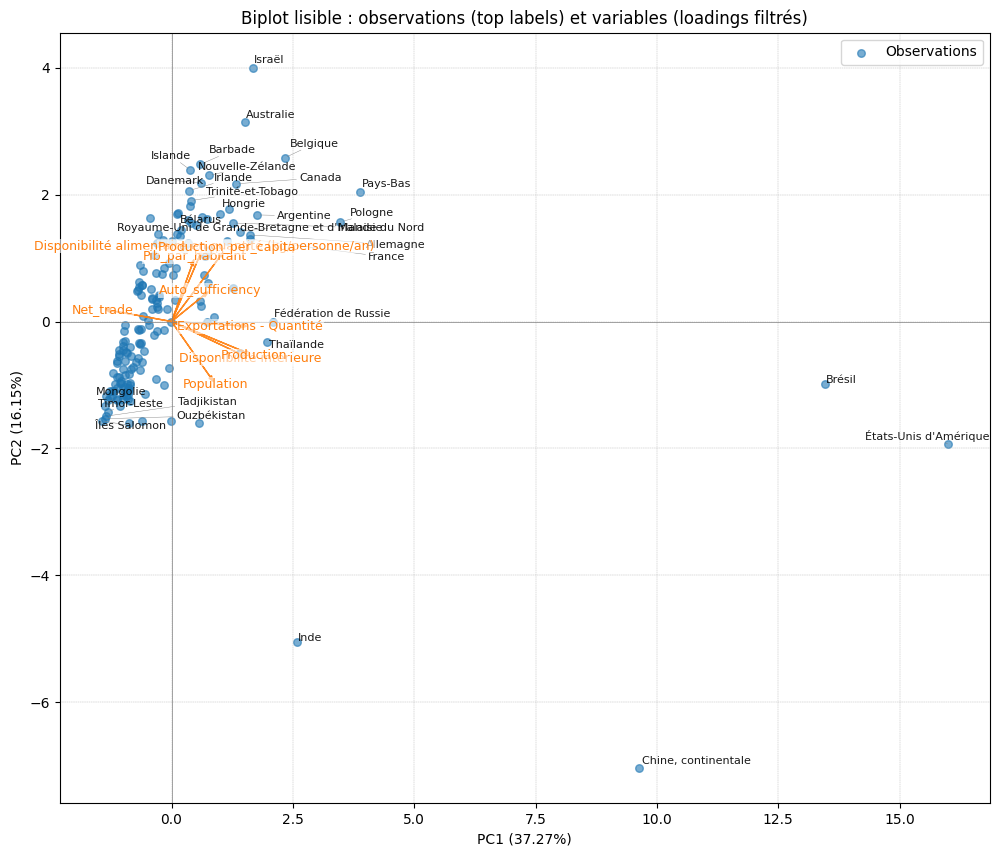

In [47]:
# Paramètres (ajustables)
figsize = (12,10)
label_top_obs = 30         # nombre de zones à annoter (top N par distance)
var_threshold = 0.25       # seuil absolu de loading pour afficher la variable (sur PC axes)
fontsz_obs = 8
fontsz_var = 9

# Vérifications et calculs préparatoires
if 'pca' not in globals():
    raise NameError("L'objet 'pca' est introuvable. Exécutez la cellule PCA avant celle-ci.")
if 'X_scaled' not in globals():
    raise NameError("La DataFrame 'X_scaled' est introuvable. Exécutez la standardisation avant la PCA.")
# Construire scores si absent
if 'scores' not in globals():
    pc_names = [f'PC{i+1}' for i in range(pca.n_components_)]
    scores = pd.DataFrame(pca.transform(X_scaled), index=X_scaled.index, columns=pc_names)

# Assurer PC1 et PC2 présents
if 'PC1' not in scores.columns or 'PC2' not in scores.columns:
    raise ValueError("scores doit contenir au moins 'PC1' et 'PC2'.")

# Construire loadings si absent
if 'loadings' not in globals():
    eigenvals = pca.explained_variance_
    components = pca.components_
    loadings_arr = components.T * np.sqrt(eigenvals[np.newaxis, :])
    var_names = X_scaled.columns.tolist()
    pc_names = [f'PC{i+1}' for i in range(loadings_arr.shape[1])]
    loadings = pd.DataFrame(loadings_arr, index=var_names, columns=pc_names)

# Construire df_with_pcs (jointure légère pour retrouver labels 'Zone' si nécessaire)
if 'df_with_pcs' not in globals():
    # essayer d'utiliser une colonne 'Zone' dans df ; sinon créer à partir de l'index
    if 'df' in globals() and 'Zone' in df.columns:
        df_with_pcs = df.copy()
        # ajouter scores au df_with_pcs (join sur index)
        df_with_pcs = df_with_pcs.join(scores[['PC1','PC2']], how='left')
    else:
        df_with_pcs = scores[['PC1','PC2']].copy()
        df_with_pcs['Zone'] = df_with_pcs.index.astype(str)

# Subset scores pour PC1/PC2
scores_sub = scores[['PC1','PC2']].copy()
# Distance au centre pour choisir top observations
dist = np.sqrt(scores_sub['PC1']**2 + scores_sub['PC2']**2)
top_obs_idx = dist.nlargest(label_top_obs).index

# Normalisation des flèches : quantile pour limiter l'impact des outliers
scale_scores = max(scores_sub['PC1'].abs().quantile(0.95), scores_sub['PC2'].abs().quantile(0.95))
scale = scale_scores if scale_scores > 0 else 1.0
arrow_scale = 0.8 * scale  # facteur ajustable

plt.figure(figsize=figsize)

# Observations
plt.scatter(scores_sub['PC1'], scores_sub['PC2'], s=30, alpha=0.6, color='C0', label='Observations')

# Annoter seulement top N observations (avec label Zone)
texts = []
for idx in top_obs_idx:
    x = scores_sub.loc[idx,'PC1']
    y = scores_sub.loc[idx,'PC2']
    label = df_with_pcs.loc[idx,'Zone'] if idx in df_with_pcs.index else str(idx)
    texts.append(plt.text(x, y, str(label), fontsize=fontsz_obs, alpha=0.9))

# Variables : choisir celles au-dessus du seuil ou top N par contribution
vars_to_plot = [v for v in loadings.index if (abs(loadings.loc[v,'PC1']) > var_threshold) or (abs(loadings.loc[v,'PC2']) > var_threshold)]
if len(vars_to_plot) == 0:
    loadings['norm12'] = np.sqrt(loadings['PC1']**2 + loadings['PC2']**2)
    vars_to_plot = loadings.sort_values('norm12', ascending=False).head(20).index.tolist()

# Tracer vecteurs (flèches) et labels variables
for var in vars_to_plot:
    lx = loadings.loc[var,'PC1']
    ly = loadings.loc[var,'PC2']
    # appliquer scale pour rendre flèches lisibles sur le plot des scores
    plt.arrow(0, 0, lx*arrow_scale, ly*arrow_scale, color='C1', alpha=0.9,
              head_width=0.03*scale, length_includes_head=True)
    plt.text(lx*arrow_scale*1.05, ly*arrow_scale*1.05, var, color='C1', fontsize=fontsz_var, ha='center', va='center',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=0.5))

# Ajuster labels pour éviter chevauchement (ne bouge que les textes d'observations)
adjust_text(texts, only_move={'points':'y','texts':'y'}, arrowprops=dict(arrowstyle='-', color='gray', lw=0.3))

plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
# Utiliser pca.explained_variance_ratio_ si présent
explained_var = getattr(pca, 'explained_variance_ratio_', None)
if explained_var is not None and len(explained_var) >= 2:
    plt.xlabel(f'PC1 ({explained_var[0]:.2%})')
    plt.ylabel(f'PC2 ({explained_var[1]:.2%})')
else:
    plt.xlabel('PC1')
    plt.ylabel('PC2')

plt.title('Biplot lisible : observations (top labels) et variables (loadings filtrés)')
plt.grid(True, linestyle='--', linewidth=0.3)
plt.legend()
plt.show()



# K-MEANS

In [48]:
# Référence : X_scaled déjà standardisé (DataFrame), index = Zone
X_for_clustering = X_scaled.copy()
print("Shape:", X_for_clustering.shape)


Shape: (169, 11)


Shape: (169, 11)


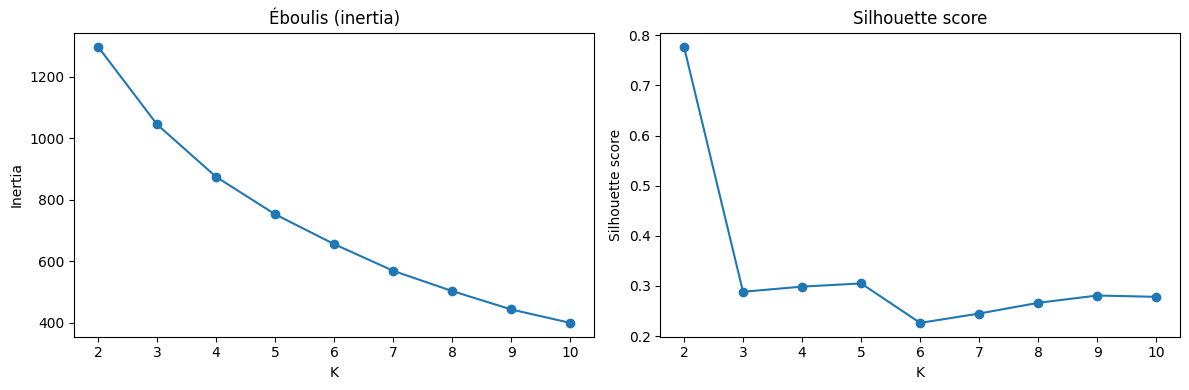

    K      inertia  silhouette
0   2  1297.508318    0.777336
1   3  1044.397671    0.288425
2   4   873.959969    0.298692
3   5   752.175781    0.305055
4   6   655.125218    0.226314
5   7   568.373704    0.245056
6   8   502.431018    0.266388
7   9   442.661996    0.280966
8  10   399.012826    0.278299


In [49]:
# Référence : X_scaled déjà standardisé (DataFrame), index = Zone
X_for_clustering = X_scaled.copy()
print("Shape:", X_for_clustering.shape)

# -------------------------
# 1) Recherche de K (inertia + silhouette)
# -------------------------
Ks = list(range(2, 11))
inertias = []
sil_scores = []

for k in Ks:
    km = KMeans(n_clusters=k, init='k-means++', n_init=50, random_state=42)
    labels = km.fit_predict(X_for_clustering)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_for_clustering, labels))

# Plot inertia et silhouette
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(Ks, inertias, '-o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Éboulis (inertia)')

plt.subplot(1,2,2)
plt.plot(Ks, sil_scores, '-o')
plt.xlabel('K')
plt.ylabel('Silhouette score')
plt.title('Silhouette score')
plt.tight_layout()
plt.show()

# Récap tableau
scores_df = pd.DataFrame({'K': Ks, 'inertia': inertias, 'silhouette': sil_scores})
print(scores_df)

# -------------------------
# 2) Fit final KMeans (choisir K retenu; exemple K_opt = 5)
# -------------------------
K_opt = 5  # adapter selon l'interprétation du graphique
kmeans = KMeans(n_clusters=K_opt, init='k-means++', n_init=50, random_state=42)
labels_final = kmeans.fit_predict(X_for_clustering)










In [50]:
# -------------------------
# 3) PCA pour projection 2D (visualisation)
# -------------------------
pca = PCA(n_components=2, random_state=42)
scores = pd.DataFrame(pca.fit_transform(X_for_clustering),
                      index=X_for_clustering.index,
                      columns=['PC1', 'PC2'])
explained_var = pca.explained_variance_ratio_

# Centroides projetés (depuis l'espace standardisé vers l'espace PCA)
centroid_scores = kmeans.cluster_centers_.dot(pca.components_.T)
centroid_x = centroid_scores[:, 0]
centroid_y = centroid_scores[:, 1]

In [51]:
# -------------------------
# 4) Construire df_clusters avec labels et projections
# -------------------------
df_clusters = X_for_clustering.copy()
df_clusters['kmeans_label'] = labels_final
df_clusters['PC1'] = scores['PC1']
df_clusters['PC2'] = scores['PC2']

# S'assurer d'avoir une colonne 'Zone' qui contient le nom du pays (copie de l'index)
df_clusters = df_clusters.reset_index().rename(columns={'index': 'Zone'})  # si l'index contient le nom du pays
# Si l'index n'est pas le nom, mais que vous avez déjà une colonne 'Zone' dans un autre DF, mappez-la avant


In [52]:
# Précondition (exécuter avant les 3 blocs suivants)
if 'Zone' not in df_clusters.columns:
    df_clusters = df_clusters.reset_index().rename(columns={'index':'Zone'})
df_clusters['Zone'] = df_clusters['Zone'].astype(str)


#STATISTIQUES DESCRIPTIVES


In [53]:
# Statistiques descriptives par cluster (robuste — remplace la cellule qui échouait)

# 0) Nom de la colonne label (KMeans)
cluster_label_col = globals().get('kmeans_label_col', 'kmeans_label')

# 1) Vérifications minimales
if 'df_clusters' not in globals():
    raise RuntimeError("df_clusters introuvable. Exécutez la cellule K-Means avant ce bloc.")
if cluster_label_col not in df_clusters.columns:
    raise KeyError(f"Colonne de label '{cluster_label_col}' introuvable dans df_clusters.")

# 2) Construire la liste des features numériques en appliquant exclusions
# Exclusions par nom exact et par motifs (ajoutez/modifiez si besoin)
exclude_exact = {cluster_label_col, 'kmeans_label', 'cah_label', '_orig_index', 'index', 'Zone', 'PC1', 'PC2'}
exclude_patterns = ['cah', 'cluster', 'label', 'centroid', 'dist', 'score', 'sil', 'silhouette', 'sample', 'flag', 'id', 'idx']
exclude_patterns = [p.replace('-', '').lower() for p in exclude_patterns]

numeric_candidates = [c for c in df_clusters.select_dtypes(include=[np.number]).columns]
features_all = []
excluded_cols = []
for c in numeric_candidates:
    low = c.lower().replace('-', '').replace(' ', '')
    if c in exclude_exact or any(p in low for p in exclude_patterns):
        excluded_cols.append(c)
    else:
        features_all.append(c)

# Optionnel : forcer l'utilisation de toutes les colonnes numériques (décommenter si souhaité)
# features_all = numeric_candidates.copy()

if not features_all:
    raise RuntimeError("Aucune feature numérique retenue après filtrage. Vérifiez les exclusions ou définissez manuellement 'features_all'.")

print(f"{len(features_all)} variables numériques retenues pour les stats.")
if excluded_cols:
    print(f"{len(excluded_cols)} colonnes exclues (exemples) : {excluded_cols[:40]}")

# 3) Calculer les statistiques descriptives par cluster
agg_funcs = ['count', 'mean', 'median', 'std', 'min', 'max']
cluster_stats = df_clusters.groupby(cluster_label_col)[features_all].agg(agg_funcs)

# 4) Aplatir les MultiIndex de colonnes pour un DataFrame lisible
cluster_stats.columns = ['_'.join(col).strip() for col in cluster_stats.columns.to_flat_index()]
cluster_stats = cluster_stats.reset_index()

# 5) Affichage arrondi
display(cluster_stats.round(4))

# Objets exposés pour la suite : features_all, excluded_cols, cluster_stats


10 variables numériques retenues pour les stats.
4 colonnes exclues (exemples) : ['_orig_index', 'kmeans_label', 'PC1', 'PC2']


,kmeans_label,Disponibilité alimentaire en quantité (kg/personne/an)_count,Disponibilité alimentaire en quantité (kg/personne/an)_mean,Disponibilité alimentaire en quantité (kg/personne/an)_median,Disponibilité alimentaire en quantité (kg/personne/an)_std,Disponibilité alimentaire en quantité (kg/personne/an)_min,Disponibilité alimentaire en quantité (kg/personne/an)_max,Disponibilité intérieure_count,Disponibilité intérieure_mean,Disponibilité intérieure_median,...,Auto_sufficiency_median,Auto_sufficiency_std,Auto_sufficiency_min,Auto_sufficiency_max,Production_per_capita_count,Production_per_capita_mean,Production_per_capita_median,Production_per_capita_std,Production_per_capita_min,Production_per_capita_max
0,0,2,-0.8027,-0.8027,0.4561,-1.1252,-0.4801,2,4.6744,4.6744,...,0.4369,0.0510,0.4008,0.4729,2,-0.4787,-0.4787,0.4160,-0.7728,-0.1846
1,1,107,-0.3776,-0.5931,0.9150,-1.2586,3.3468,107,-0.2380,-0.2895,...,-0.1106,0.8045,-1.5487,1.1804,107,-0.5793,-0.7403,0.3693,-0.9258,0.3678
2,2,50,0.6449,0.5570,0.7482,-0.4597,3.0329,50,-0.0208,-0.2262,...,0.4622,1.0676,-1.5487,4.5840,50,1.0923,0.9433,0.8834,-0.9258,3.4811
3,3,2,2.0417,2.0417,0.3451,1.7977,2.2858,2,6.1431,6.1431,...,1.0911,0.3174,0.8667,1.3156,2,2.9942,2.9942,0.0375,2.9677,3.0207
4,4,8,0.7099,0.7896,0.6327,-0.0865,1.5067,8,0.6093,0.5683,...,0.0610,0.6273,-1.3142,0.6911,8,0.2930,0.3636,0.4618,-0.6336,0.7631


In [54]:
# Boxplots interactifs paginés simples (Plotly) — version robuste
import math
import numpy as np
import plotly.express as px
from IPython.display import display, HTML

# Paramètres
cluster_label_col = globals().get('kmeans_label_col', 'kmeans_label')
PAGE_SIZE = 12
FIGWIDTH = 900
FIGHEIGHT = 450
SHOW_POINTS = True   # True -> points affichés (hover), False -> pas de points
CLIP_PERCENTILE = globals().get('CLIP_PERCENTILE', None)  # optionnel

# Vérifs rapides
if 'df_clusters' not in globals():
    raise RuntimeError("df_clusters introuvable. Exécutez la cellule K-Means avant ce bloc.")
if cluster_label_col not in df_clusters.columns:
    raise KeyError(f"Colonne de label '{cluster_label_col}' introuvable dans df_clusters.")

# Préparer features_all (déjà filtré auparavant) ou détecter automatiquement
if 'features_all' in globals() and features_all:
    vars_all = list(features_all)
else:
    exclude_meta = {cluster_label_col, 'cah_label', '_orig_index', 'index', 'Zone', 'PC1', 'PC2'}
    exclude_patterns = ['cah','cluster','label','centroid','dist','score','sil','sample']
    candidates = [c for c in df_clusters.select_dtypes(include=[np.number]).columns if c not in exclude_meta]
    vars_all = [c for c in candidates if not any(p in c.lower().replace('-','') for p in exclude_patterns)]
if not vars_all:
    raise RuntimeError("Aucune variable numérique détectée pour tracer. Définissez 'features_all' manuellement.")

# Préparer df pour affichage : copier, convertir label en str, appliquer clipping si demandé
df_plot = df_clusters.copy()
df_plot[cluster_label_col] = df_plot[cluster_label_col].astype(str)

if CLIP_PERCENTILE is not None:
    for c in vars_all:
        vals = df_plot[c].dropna().values
        if vals.size == 0:
            continue
        lo = np.percentile(vals, (100 - CLIP_PERCENTILE) / 2) if CLIP_PERCENTILE < 100 else vals.min()
        hi = np.percentile(vals, CLIP_PERCENTILE)
        df_plot[c] = df_plot[c].clip(lower=lo, upper=hi)

# Pagination et affichage simple avec plotly.express
n_plots = len(vars_all)
n_pages = math.ceil(n_plots / PAGE_SIZE)

for page in range(n_pages):
    start = page * PAGE_SIZE
    end = min(start + PAGE_SIZE, n_plots)
    page_vars = vars_all[start:end]

    for v in page_vars:
        points_arg = 'all' if SHOW_POINTS else False
        fig = px.box(df_plot, x=cluster_label_col, y=v, color=cluster_label_col,
                     points=points_arg, color_discrete_sequence=px.colors.qualitative.Plotly)
        fig.update_layout(
            title=f"Boxplot interactif — {v} (page {page+1}/{n_pages})",
            width=FIGWIDTH, height=FIGHEIGHT,
            xaxis_title="Cluster", yaxis_title=v,
            showlegend=False
        )
        fig.update_traces(hovertemplate=f"%{{x}}<br>{v}: %{{y:.3f}}<extra></extra>")
        display(fig)

    display(HTML(f"<hr><p style='font-size:14px'>Page {page+1} / {n_pages} — variables {start+1}–{end} / {n_plots}</p>"))


Centroïdes KMeans utilisés : mean_by_kmeans — shape (5, 10)


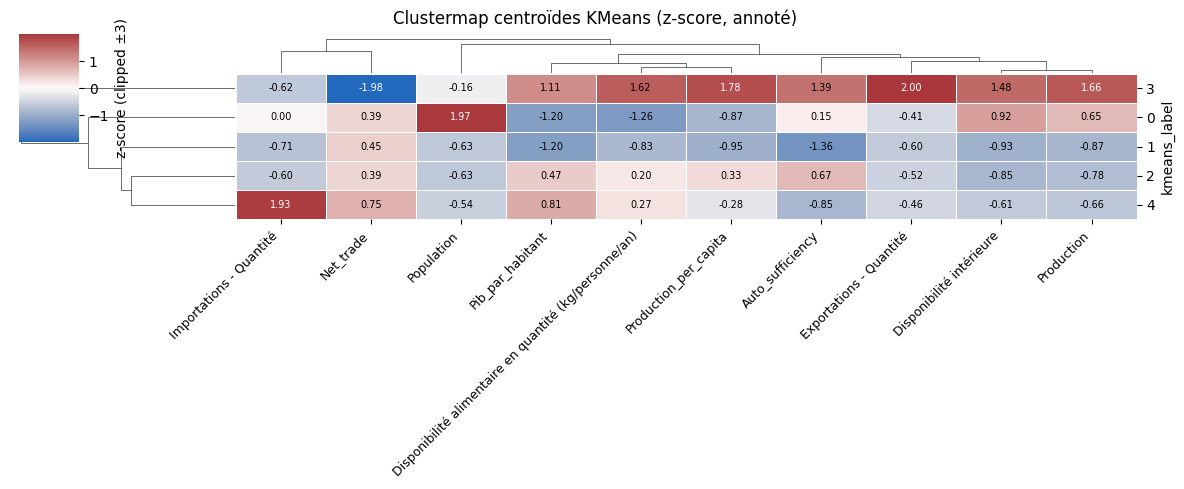

In [55]:
# Clustermap K-Means annoté — code complet

# Paramètres ajustables
CLIP_Z = 3                       # clip z-score à +/- CLIP_Z
MAX_VARS_FOR_CLUSTERMAP = 60     # si plus de variables, on prend les plus discriminantes
FIG_WIDTH = 12
FIG_HEIGHT_PER_VAR = 0.18
ANNOT_FONT_SIZE = 7              # taille du texte dans les cellules

# 0) Vérifs et construction de centroids_df_k si nécessaire
if 'df_clusters' not in globals():
    raise RuntimeError("df_clusters introuvable. Exécutez la cellule K-Means avant ce bloc.")

# Détecter features candidates pour KMeans si non fournies
if 'feat_cols_kmeans' in globals() and feat_cols_kmeans:
    feat_cols_k = list(feat_cols_kmeans)
else:
    # heuristique : toutes les colonnes numériques sauf métadonnées évidentes
    exclude_meta = {'kmeans_label','cah_label','_orig_index','index','Zone','PC1','PC2'}
    exclude_patterns = ['cah','cluster','label','centroid','dist','score']
    feat_cols_k = [c for c in df_clusters.select_dtypes(include=[np.number]).columns
                   if c not in exclude_meta and not any(p in c.lower() for p in exclude_patterns)]
    if not feat_cols_k:
        raise RuntimeError("Aucune feature numérique valide détectée pour KMeans. Définissez feat_cols_kmeans manuellement.")

# Construire centroids_df_k : préférence centres KMeans inverse-scalés
centroids_sources_k = {}
if 'kmeans' in globals() and hasattr(kmeans, 'cluster_centers_'):
    try:
        centers = kmeans.cluster_centers_
        if 'scaler' in globals():
            try:
                centers_orig = scaler.inverse_transform(centers)
                centroids_sources_k['kmeans_centers_inverse_scaled'] = pd.DataFrame(centers_orig, columns=feat_cols_k)
            except Exception:
                centroids_sources_k['kmeans_centers_raw'] = pd.DataFrame(centers, columns=feat_cols_k)
        else:
            centroids_sources_k['kmeans_centers_raw'] = pd.DataFrame(centers, columns=feat_cols_k)
    except Exception:
        pass

# fallback : moyennes par label KMeans
if 'kmeans_label' in df_clusters.columns:
    centroids_sources_k['mean_by_kmeans'] = df_clusters.groupby('kmeans_label')[feat_cols_k].mean()

if not centroids_sources_k:
    raise RuntimeError("Impossible de construire centroids_df_k automatiquement. Définissez centroids_df_k manuellement.")

# choisir la source disponible (préférence ordre d'insertion ci‑dessus)
chosen_key_k = list(centroids_sources_k.keys())[0]
centroids_df_k = centroids_sources_k[chosen_key_k].copy()
centroids_df_k.index = centroids_df_k.index.astype(int) if hasattr(centroids_df_k.index, 'astype') else centroids_df_k.index

print(f"Centroïdes KMeans utilisés : {chosen_key_k} — shape {centroids_df_k.shape}")

# 1) Préparer cent_z (z-score) et clipping
centroids_df_k = centroids_df_k.select_dtypes(include=[np.number]).copy()
if centroids_df_k.empty:
    raise RuntimeError("centroids_df_k ne contient pas de colonnes numériques après filtrage.")

cent_z = (centroids_df_k - centroids_df_k.mean()) / centroids_df_k.std(ddof=0)
cent_z = cent_z.clip(lower=-CLIP_Z, upper=CLIP_Z)

# 2) Réduire variables si trop nombreuses (garder les plus discriminantes)
n_vars = cent_z.shape[1]
if n_vars > MAX_VARS_FOR_CLUSTERMAP:
    var_importance = cent_z.abs().mean(axis=0).sort_values(ascending=False)
    top_vars = var_importance.index[:MAX_VARS_FOR_CLUSTERMAP].tolist()
    cent_z = cent_z[top_vars]
    print(f"Réduction à {len(top_vars)} variables les plus discriminantes pour le clustermap (sur {n_vars} initiales).")

# 3) Clustermap et annotation des valeurs dans les cellules
fig_h = max(6, cent_z.shape[0] * FIG_HEIGHT_PER_VAR + 3)
fig_w = FIG_WIDTH

try:
    cg = sns.clustermap(
        cent_z,
        cmap='vlag',
        center=0,
        figsize=(fig_w, fig_h),
        linewidths=0.4,
        cbar_kws={'label': f'z-score (clipped ±{CLIP_Z})'},
        method='average',
        metric='euclidean'
    )
    plt.suptitle("Clustermap centroïdes KMeans (z-score, annoté)", y=1.02)

    # récupérer la matrice dans l'ordre réordonné par clustermap
    try:
        row_idx = cg.dendrogram_row.reordered_ind
        col_idx = cg.dendrogram_col.reordered_ind
        data = cent_z.iloc[row_idx, :].iloc[:, col_idx]
    except Exception:
        data = cent_z.copy()

    ax = cg.ax_heatmap

    # Annoter chaque cellule ; ajuster couleur du texte selon contraste
    for i, row in enumerate(data.index):
        for j, col in enumerate(data.columns):
            val = data.iloc[i, j]
            # contraste : texte clair sur valeurs extrêmes, sombre sinon
            text_color = 'white' if abs(val) > (CLIP_Z * 0.55) else 'black'
            ax.text(j + 0.5, i + 0.5, f"{val:.2f}", ha='center', va='center',
                    fontsize=ANNOT_FONT_SIZE, color=text_color)

    plt.setp(cg.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    plt.setp(cg.ax_heatmap.get_yticklabels(), rotation=0, fontsize=10)
    plt.show()

except Exception as e:
    print("Erreur clustermap :", e)
    # fallback : heatmap annotée (ordre original)
    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(cent_z, cmap='vlag', center=0, annot=True, fmt='.2f',
                annot_kws={'fontsize': ANNOT_FONT_SIZE}, linewidths=0.4,
                cbar_kws={'label': f'z-score (clipped ±{CLIP_Z})'})
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=10)
    plt.title("Heatmap centroïdes KMeans (fallback, annotée)")
    plt.tight_layout()
    plt.show()


In [82]:
# Descriptions automatiques par cluster pour K-Means (inspiré de la version CAH)
import numpy as np
import pandas as pd
from IPython.display import display

# Paramètres
kmeans_label_col = globals().get('kmeans_label_col', 'kmeans_label')  # nom de la colonne label KMeans
TOP_N = 4   # nb variables hautes/basses à mentionner
# Vérifs minimales
if 'df_clusters' not in globals():
    raise RuntimeError("df_clusters introuvable. Exécutez la cellule K-Means avant ce bloc.")
if kmeans_label_col not in df_clusters.columns:
    raise KeyError(f"Colonne '{kmeans_label_col}' introuvable dans df_clusters.")

# 1) Construire / récupérer centroids_df_k, centroids_std_k, counts_k, global_mean_k
# Préférence : centroids_df_k déjà calculé (ex. à partir de kmeans + scaler), sinon moyennes par label
if 'centroids_df_k' in globals():
    centroids_df_k = centroids_df_k.copy()
    chosen_source = 'centroids_df_k (préexistante)'
else:
    # fallback : moyennes par label (sur colonnes numériques filtrées)
    # on tente d'utiliser les mêmes colonnes numériques que df_clusters (hors métadonnées)
    numeric_cols = [c for c in df_clusters.select_dtypes(include=[np.number]).columns]
    exclude_meta = {kmeans_label_col, 'cah_label', '_orig_index', 'index', 'PC1', 'PC2', 'Zone'}
    feat_cols_k = [c for c in numeric_cols if c not in exclude_meta]
    if not feat_cols_k:
        feat_cols_k = numeric_cols.copy()
    centroids_df_k = df_clusters.groupby(kmeans_label_col)[feat_cols_k].mean()
    chosen_source = 'mean_by_kmeans (fallback)'

# s'assurer que centroids_df_k contient uniquement colonnes numériques
centroids_df_k = centroids_df_k.select_dtypes(include=[np.number]).copy()
if centroids_df_k.empty:
    raise RuntimeError("centroids_df_k ne contient pas de colonnes numériques après filtrage.")

# dispersion intra-cluster (std), effectifs et moyenne globale (sur mêmes colonnes)
common_cols = [c for c in centroids_df_k.columns if c in df_clusters.select_dtypes(include=[np.number]).columns]
centroids_std_k = df_clusters.groupby(kmeans_label_col)[common_cols].std()
counts_k = df_clusters.groupby(kmeans_label_col).size().rename('n_obs')
global_mean_k = df_clusters[common_cols].mean()

# 2) Fonction describe_cluster_k (même style que votre version CAH)
def describe_cluster_k(cluster_id, centroids_df, centroids_std, counts, global_mean, top_n=5):
    # récupérer valeurs du centroïde (alignées sur global_mean)
    mean_vals = centroids_df.loc[cluster_id].reindex(global_mean.index).astype(float)
    std_vals = centroids_std.loc[cluster_id] if cluster_id in centroids_std.index else pd.Series(np.nan, index=centroids_df.columns)
    n = int(counts.loc[cluster_id]) if cluster_id in counts.index else 0

    # variables les plus élevées et les plus faibles (relativement à la moyenne globale)
    rel = (mean_vals - global_mean)
    top_high = rel.sort_values(ascending=False).head(top_n).index.tolist()
    top_low = rel.sort_values(ascending=True).head(top_n).index.tolist()

    # construire texte
    lines = []
    lines.append(f"Cluster {cluster_id} — n = {n} observations ({n/len(df_clusters)*100:.1f}%)")
    lines.append("Profil synthétique :")
    # phrase sur variables élevées
    if top_high:
        vals = ', '.join([f"{v} (moy={mean_vals[v]:.2f})" for v in top_high])
        lines.append(f"  • Variables nettement supérieures à la moyenne : {vals}.")
    # phrase sur variables faibles
    if top_low:
        vals = ', '.join([f"{v} (moy={mean_vals[v]:.2f})" for v in top_low])
        lines.append(f"  • Variables nettement inférieures à la moyenne : {vals}.")
    # dispersion (3 variables les plus dispersées)
    high_var = std_vals.sort_values(ascending=False).head(3).index.tolist()
    if high_var:
        lines.append(f"  • Variables avec forte dispersion intra-cluster : {', '.join(high_var)}.")
    return "\n".join(lines)

# 3) Afficher les descriptions pour tous les clusters KMeans
print(f"Descriptions automatiques KMeans (centroïdes source: {chosen_source})\n")
for cl in sorted(centroids_df_k.index):
    desc = describe_cluster_k(cl, centroids_df_k, centroids_std_k, counts_k, global_mean_k, top_n=TOP_N)
    print(desc)
    print("-" * 80)

# Objets exposés : centroids_df_k, centroids_std_k, counts_k, global_mean_k


Descriptions automatiques KMeans (centroïdes source: centroids_df_k (préexistante))

Cluster 0 — n = 2 observations (1.2%)
Profil synthétique :
  • Variables nettement supérieures à la moyenne : Population (moy=8.68), Disponibilité intérieure (moy=4.67), Production (moy=4.09), Importations - Quantité (moy=0.81).
  • Variables nettement inférieures à la moyenne : Disponibilité alimentaire en quantité (kg/personne/an) (moy=-0.80), Production_per_capita (moy=-0.48), Pib_par_habitant (moy=-0.43), Net_trade (moy=-0.09).
  • Variables avec forte dispersion intra-cluster : Disponibilité intérieure, Production, Importations - Quantité.
--------------------------------------------------------------------------------
Cluster 1 — n = 107 observations (63.3%)
Profil synthétique :
  • Variables nettement supérieures à la moyenne : Net_trade (moy=0.11), Population (moy=-0.14), Exportations - Quantité (moy=-0.21), Production (moy=-0.24).
  • Variables nettement inférieures à la moyenne : Production_p

In [56]:
# Fonction corrigée et robuste pour trouver observations représentatives
import numpy as np
import pandas as pd

def top_representatives(cluster_id, centroids_df, df, label_col, n=5, name_col='Zone'):
    """
    Retourne une liste de n observations les plus proches du centroïde du cluster_id.
    - centroids_df : DataFrame index=cluster_id, colonnes=features numériques
    - df : DataFrame contenant les mêmes features et la colonne label_col
    """
    if cluster_id not in df[label_col].unique():
        return []
    # déterminer features communes entre centroid et df (numériques)
    feat_cols = [c for c in centroids_df.columns if c in df.select_dtypes(include=[np.number]).columns]
    if not feat_cols:
        return []

    # extraire le centroïde comme Series indexée par feature
    centroid_series = centroids_df.loc[cluster_id, feat_cols]
    # si centroid_series est ndarray ou contient des valeurs non scalaires, forcer Series
    if isinstance(centroid_series, np.ndarray):
        centroid_series = pd.Series(centroid_series, index=feat_cols)

    # subset des observations du cluster
    subset = df[df[label_col] == cluster_id].copy()
    if subset.empty:
        return []

    # remplir NA colonne par colonne avec la valeur du centroïde (mapping dict)
    fill_map = centroid_series.to_dict()
    # appliquer fillna uniquement sur les colonnes présentes
    subset_feats = subset[feat_cols].fillna(value=fill_map)

    # calculer distances euclidiennes (après conversion en float)
    X = subset_feats.astype(float).values
    centroid_vec = centroid_series.astype(float).values.reshape(1, -1)
    dists = np.linalg.norm(X - centroid_vec, axis=1)

    subset = subset.assign(_dist_to_centroid=dists)
    subset = subset.sort_values('_dist_to_centroid')

    # construire liste de noms représentatifs
    reps = []
    for _, row in subset.head(n).iterrows():
        if name_col in row and pd.notna(row[name_col]):
            reps.append(str(row[name_col]))
        else:
            # si pas de colonne descriptive, utiliser l'index (ou un identifiant)
            reps.append(str(row.name))
    return reps


## AFFICHAGE NOM

In [57]:
# 0) Préconditions : exécuter après avoir chargé X_for_clustering et df
# Vérifier que X_for_clustering et df existent, et reconstruire mapping code->nom
assert 'X_for_clustering' in globals(), "X_for_clustering absent"
assert 'df' in globals(), "df absent"
# Construire mapping explicite si vous connaissez les colonnes (sinon automatisation ci‑dessous)
# Exemple explicite si df contient 'Zone' (codes) et 'Zone_name' ou 'Pays' (noms) :
# mapping = df.set_index('Zone')['Pays'].astype(str).to_dict()

# Détection automatique simple (fallback si vous n'indiquez pas les colonnes)
name_cols = [c for c in df.columns if df[c].dtype == object]
mapping = {}
# Tentative 1 : si df.index correspond aux codes et df a une colonne de noms
if len(name_cols) > 0 and set(map(str, df.index)).intersection(set(df_clusters['Zone'].astype(str).unique())):
    name_col = name_cols[0]
    mapping = {str(k): str(v) for k,v in df[name_col].to_dict().items()}
else:
    # Tentative 2 : trouver colonne contenant codes puis une colonne de noms
    best_code_col, best_match = None, 0
    codes = set(df_clusters['Zone'].astype(str).unique())
    for col in df.columns:
        score = len(set(df[col].astype(str)).intersection(codes))
        if score > best_match:
            best_match = score
            best_code_col = col
    if best_code_col and best_match > 0:
        # choisir une colonne de noms différente de best_code_col
        name_col = next((c for c in name_cols if c != best_code_col), None)
        if name_col:
            mapping = {str(k): str(v) for k,v in df.set_index(best_code_col)[name_col].to_dict().items()}

# Appliquer mapping (toujours convertir en str pour éviter mismatch)
df_clusters['Zone'] = df_clusters.get('Zone', df_clusters.index).astype(str)
if mapping:
    df_clusters['Zone'] = df_clusters['Zone'].map(lambda k: mapping.get(k, k)).astype(str)
else:
    print("Aucun mapping automatique trouvé — vérifiez df et indiquez explicitement mapping.")
# Vérification rapide
print(df_clusters[['Zone']].head(10))
print("dtype Zone:", df_clusters['Zone'].dtype)


                 Zone
0         Afghanistan
1      Afrique du Sud
2             Albanie
3             Algérie
4           Allemagne
5              Angola
6  Antigua-et-Barbuda
7     Arabie saoudite
8           Argentine
9             Arménie
dtype Zone: object


In [58]:
# Bloc A : effectifs et liste complète par cluster (affichage en lignes de 10)
print("\nEffectifs par cluster :")
print(df_clusters['kmeans_label'].value_counts().sort_index())

print("\nPays par cluster :")
for c in sorted(df_clusters['kmeans_label'].unique()):
    names = df_clusters.loc[df_clusters['kmeans_label'] == c, 'Zone'].astype(str).tolist()
    print(f"Cluster {c} (n={len(names)}):")
    for i in range(0, len(names), 10):
        print("  " + ", ".join(names[i:i+10]))
    print('-'*80)



Effectifs par cluster :
kmeans_label
0      2
1    107
2     50
3      2
4      8
Name: count, dtype: int64

Pays par cluster :
Cluster 0 (n=2):
  Chine, continentale, Inde
--------------------------------------------------------------------------------
Cluster 1 (n=107):
  Afghanistan, Albanie, Algérie, Angola, Antigua-et-Barbuda, Arménie, Azerbaïdjan, Bangladesh, Bosnie-Herzégovine, Botswana
  Bulgarie, Burkina Faso, Bénin, Cabo Verde, Cambodge, Cameroun, Congo, Croatie, Cuba, Côte d'Ivoire
  Djibouti, Dominique, El Salvador, Estonie, Eswatini, Gabon, Gambie, Ghana, Grenade, Guatemala
  Guinée, Guinée-Bissau, Géorgie, Haïti, Honduras, Indonésie, Iraq, Jordanie, Kazakhstan, Kenya
  Kirghizistan, Kiribati, Lesotho, Lettonie, Liban, Libéria, Macédoine du Nord, Madagascar, Malawi, Maldives
  Mali, Malte, Maroc, Mauritanie, Mongolie, Monténégro, Mozambique, Namibie, Nicaragua, Niger
  Nigéria, Nouvelle-Calédonie, Népal, Oman, Ouganda, Ouzbékistan, Pakistan, Paraguay, Philippines, Polynés

In [59]:
# Bloc B : top N par cluster (proches du centroïde)
N = 8
for c in range(kmeans.n_clusters):
    subset = df_clusters[df_clusters['kmeans_label'] == c].copy()
    if subset.empty:
        continue
    dx = subset['PC1'].values - centroid_x[c]
    dy = subset['PC2'].values - centroid_y[c]
    dists = np.sqrt(dx**2 + dy**2)
    top_pos = np.argsort(dists)[:min(N, len(dists))]
    top_names = subset.iloc[top_pos]['Zone'].tolist()
    print(f"Cluster {c} — top {len(top_names)} pays proches du centroïde:")
    print(top_names)
    print('-'*50)


Cluster 0 — top 2 pays proches du centroïde:
['Chine, continentale', 'Inde']
--------------------------------------------------
Cluster 1 — top 8 pays proches du centroïde:
['Eswatini', 'Paraguay', 'Serbie', 'Cameroun', 'Monténégro', 'Botswana', 'Burkina Faso', 'Géorgie']
--------------------------------------------------
Cluster 2 — top 8 pays proches du centroïde:
['Chili', 'Lituanie', 'Bolivie (État plurinational de)', 'Panama', 'Portugal', 'Espagne', 'Bélarus', 'Belize']
--------------------------------------------------
Cluster 3 — top 2 pays proches du centroïde:
['Brésil', "États-Unis d'Amérique"]
--------------------------------------------------
Cluster 4 — top 8 pays proches du centroïde:
['Afrique du Sud', 'Japon', "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord", 'France', 'Allemagne', 'Mexique', 'Arabie saoudite', 'Émirats arabes unis']
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but PCA was fitted with feature names

/tmp/ipython-input-830172809.py:42: UserWarning:

The palette list has more values (10) than needed (5), which may not be intended.



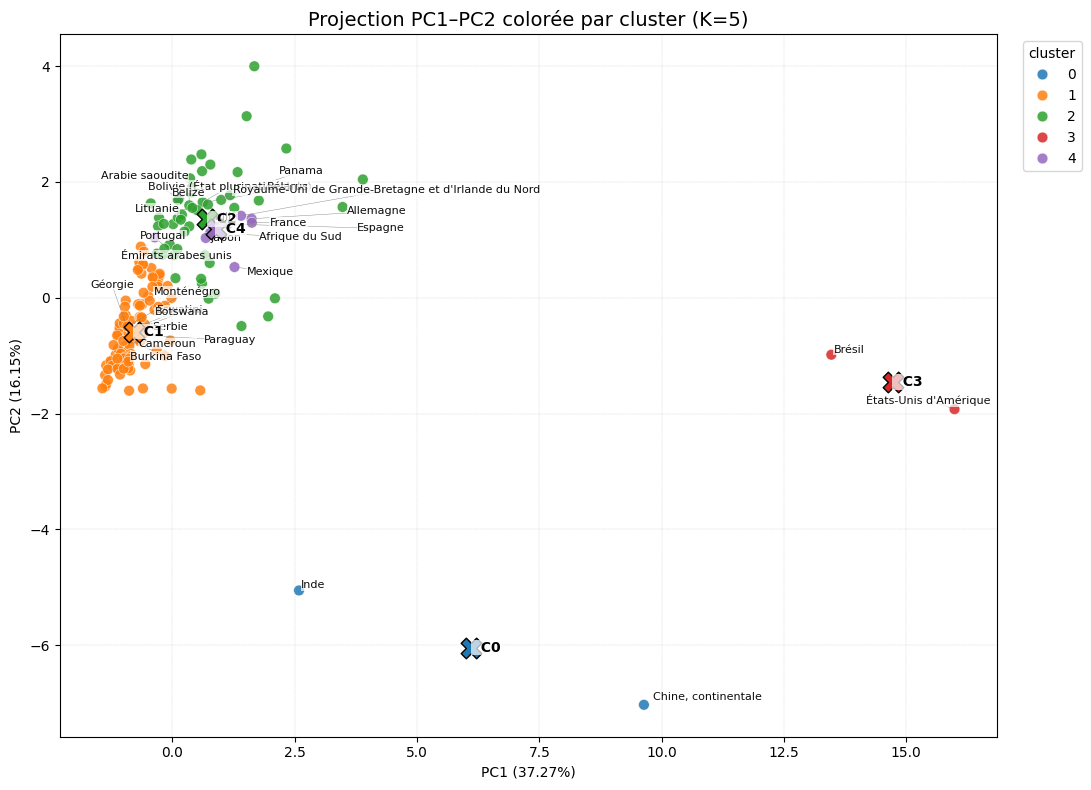

In [60]:
# Assurer cohérence K
K_opt = 5  # s'assurer que c'est bien la valeur retenue
assert hasattr(kmeans, 'n_clusters'), "Objet kmeans non défini correctement"
if kmeans.n_clusters != K_opt:
    print(f"Attention : kmeans.n_clusters = {kmeans.n_clusters} mais K_opt = {K_opt}. On force l'affichage sur K_opt.")

# Centroides en espace PC (si centres en espace standardisé)
# Si kmeans a été entraîné sur X_for_clustering (X_scaled), les centres sont en échelle standardisée,
# il est cohérent d'utiliser directement les coordonnées sur PC (centres projetés).
# Ici on calcule les centroides dans l'espace des composantes (PC1, PC2) en projetant les centres
# des variables standardisées sur les composantes si nécessaire. Si vous avez déjà les centres en PC,
# vous pouvez remplacer la logique ci‑dessous par centroid_x = ... centroid_y = ...
if 'scores' in globals() and 'X_scaled' in globals():
    # Calculer centroides en PC en transformant les centres de kmeans via PCA
    # centres_scaled = kmeans.cluster_centers_ (en espace X_scaled)
    try:
        centers_scaled = kmeans.cluster_centers_
        centers_pcs = pca.transform(centers_scaled)[:, :2]  # shape (K,2)
        centroid_x = centers_pcs[:, 0]
        centroid_y = centers_pcs[:, 1]
    except Exception:
        # si transformation impossible, tenter récupération directe si df_clusters contient moyennes PC
        centroid_x = []
        centroid_y = []
        for c in range(kmeans.n_clusters):
            sub = df_clusters[df_clusters['kmeans_label']==c]
            centroid_x.append(sub['PC1'].mean() if not sub.empty else np.nan)
            centroid_y.append(sub['PC2'].mean() if not sub.empty else np.nan)
        centroid_x = np.array(centroid_x); centroid_y = np.array(centroid_y)
else:
    centroid_x = []
    centroid_y = []
    for c in range(kmeans.n_clusters):
        sub = df_clusters[df_clusters['kmeans_label']==c]
        centroid_x.append(sub['PC1'].mean() if not sub.empty else np.nan)
        centroid_y.append(sub['PC2'].mean() if not sub.empty else np.nan)
    centroid_x = np.array(centroid_x); centroid_y = np.array(centroid_y)

# Tracé principal
plt.figure(figsize=(11,8))
palette = sns.color_palette('tab10', n_colors=max(10, kmeans.n_clusters))
scatter = sns.scatterplot(x='PC1', y='PC2', hue='kmeans_label', data=df_clusters,
                palette=palette, s=60, alpha=0.85, edgecolor='w', linewidth=0.4)

# Centroides (marqueur X) et étiquettes de centroïdes
for c in range(kmeans.n_clusters):
    plt.scatter(centroid_x[c], centroid_y[c], marker='X', s=220,
                color=[palette[c]], edgecolor='k', linewidth=1.0, zorder=5)
    plt.text(centroid_x[c], centroid_y[c], f'  C{c}', fontsize=10, fontweight='bold', va='center', zorder=6,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.6))

# Annoter top N proches du centroïde (N plus petit si cluster petit)
N = 8
texts = []
for c in range(kmeans.n_clusters):
    subset = df_clusters[df_clusters['kmeans_label'] == c].copy()
    if subset.empty:
        continue
    dx = subset['PC1'].values - centroid_x[c]
    dy = subset['PC2'].values - centroid_y[c]
    dists = np.sqrt(dx**2 + dy**2)
    top_pos = np.argsort(dists)[:min(N, len(dists))]
    for pos in top_pos:
        x = subset.iloc[pos]['PC1']; y = subset.iloc[pos]['PC2']
        name = subset.iloc[pos]['Zone']
        txt = plt.text(x, y, name, fontsize=8, alpha=0.95, zorder=4,
                       bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.4))
        texts.append(txt)

# Améliorer lisibilité des labels via adjust_text (déplace légèrement les textes)
if texts:
    adjust_text(texts, only_move={'points':'y','texts':'y'}, expand_text=(1.02,1.2),
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.3), autoalign='y')

# Éléments graphiques finaux
explained_var = getattr(pca, 'explained_variance_ratio_', None)
if explained_var is not None and len(explained_var) >= 2:
    xlabel = f'PC1 ({explained_var[0]:.2%})'
    ylabel = f'PC2 ({explained_var[1]:.2%})'
else:
    xlabel = 'PC1'; ylabel = 'PC2'

plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(f'Projection PC1–PC2 colorée par cluster (K={K_opt})', fontsize=14)
# améliorer légende (compacte) et la placer
plt.legend(title='cluster', bbox_to_anchor=(1.02,1), loc='upper left', frameon=True)
plt.grid(True, linestyle='--', linewidth=0.3, alpha=0.6)
plt.tight_layout()
plt.show()


## CAH


In [61]:
# Préconditions : X_for_clustering (DataFrame ou array) et df_clusters existent

assert 'X_for_clustering' in globals(), "X_for_clustering absent"
assert 'df_clusters' in globals(), "df_clusters absent"

# Utiliser une copie standardisée si nécessaire (X_for_clustering doit être centrée/réduite pour Ward)
X = X_for_clustering.values if hasattr(X_for_clustering, "values") else np.asarray(X_for_clustering)


In [62]:
# Calcule la matrice de linkage (coûteux en O(n^2))
from scipy.cluster.hierarchy import linkage

method = 'ward'        # recommandé pour données numériques standardisées
metric = 'euclidean'   # utilisé implicitement par ward

Z = linkage(X, method=method, metric=metric)   # matrice de linkage (n_samples-1, 4)
# Sauvegarde optionnelle pour réutilisation
# import pickle
# with open('linkage_Z.pkl','wb') as f: pickle.dump(Z,f)
print("Linkage calculé, shape:", Z.shape)


Linkage calculé, shape: (168, 4)


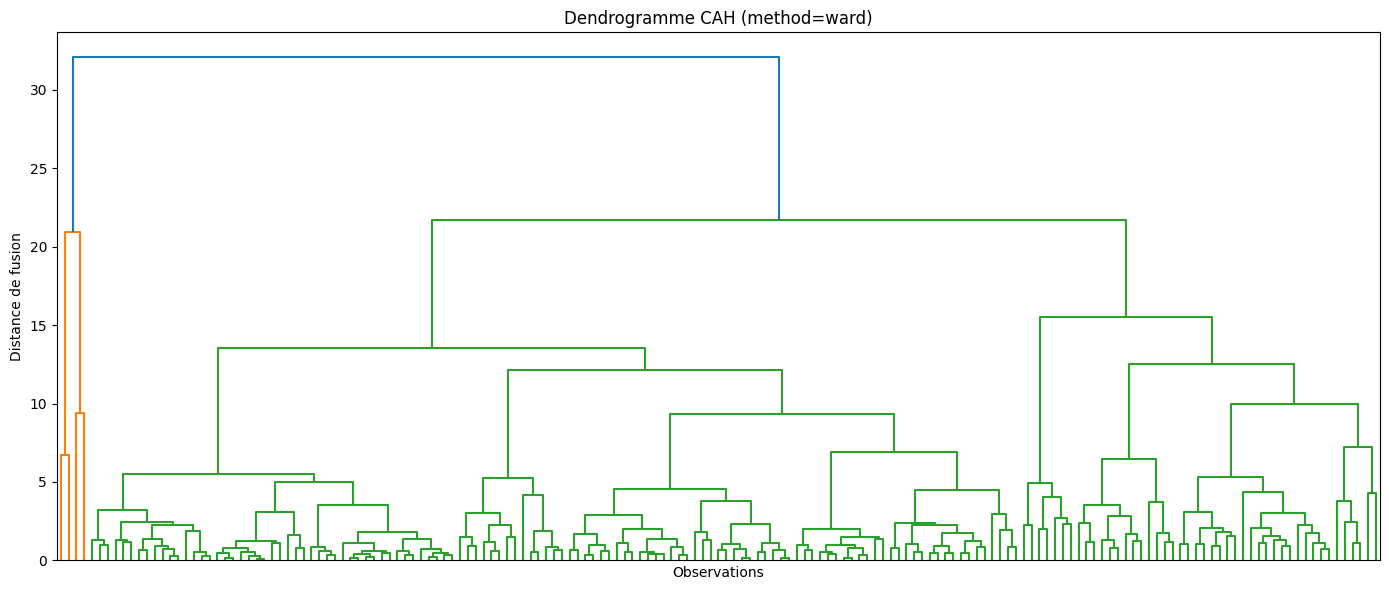

In [63]:

import matplotlib.pyplot as plt

# Option A : dendrogramme complet (utile si n modéré)
plt.figure(figsize=(14,6))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title(f'Dendrogramme CAH (method={method})')
plt.ylabel('Distance de fusion')
plt.xlabel('Observations')
plt.tight_layout()
plt.show()



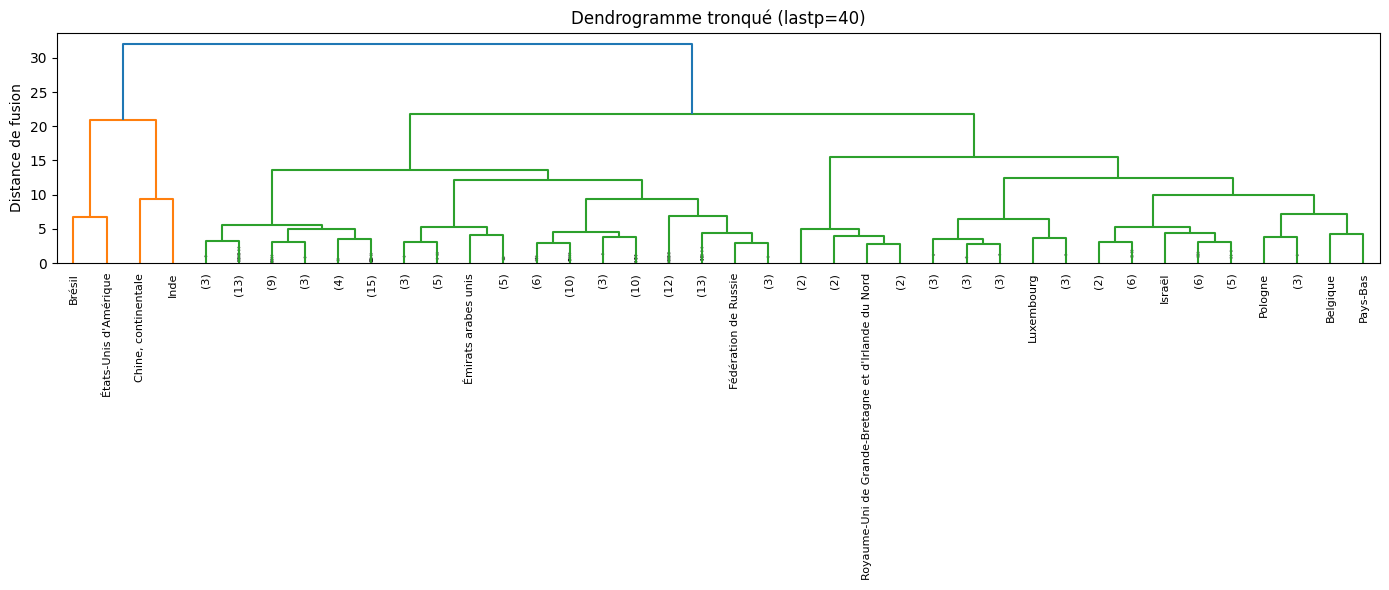

In [64]:
# Option B : dendrogramme tronqué (utile si n grand)
plt.figure(figsize=(14,6))
dendrogram(Z, labels=df_clusters['Zone'].values, truncate_mode='lastp', p=40,
           leaf_rotation=90, leaf_font_size=8, show_contracted=True,
           color_threshold=0.7*max(Z[:,2]))
plt.title('Dendrogramme tronqué (lastp=40)')
plt.ylabel('Distance de fusion')
plt.tight_layout()
plt.show()

In [65]:
from scipy.cluster.hierarchy import fcluster

k = 5
labels_cah = fcluster(Z, t=k, criterion='maxclust')  # renvoie labels 1..k
# Optionnel : normaliser en 0..k-1
labels_cah_zero = labels_cah - 1

# Ajouter au DataFrame
df_clusters['cah_label'] = labels_cah_zero
print("Répartition CAH (k=5) :")
print(df_clusters['cah_label'].value_counts().sort_index())


Répartition CAH (k=5) :
cah_label
0      2
1      2
2    119
3      7
4     39
Name: count, dtype: int64


/tmp/ipython-input-3476949345.py:12: UserWarning:

The palette list has more values (10) than needed (5), which may not be intended.



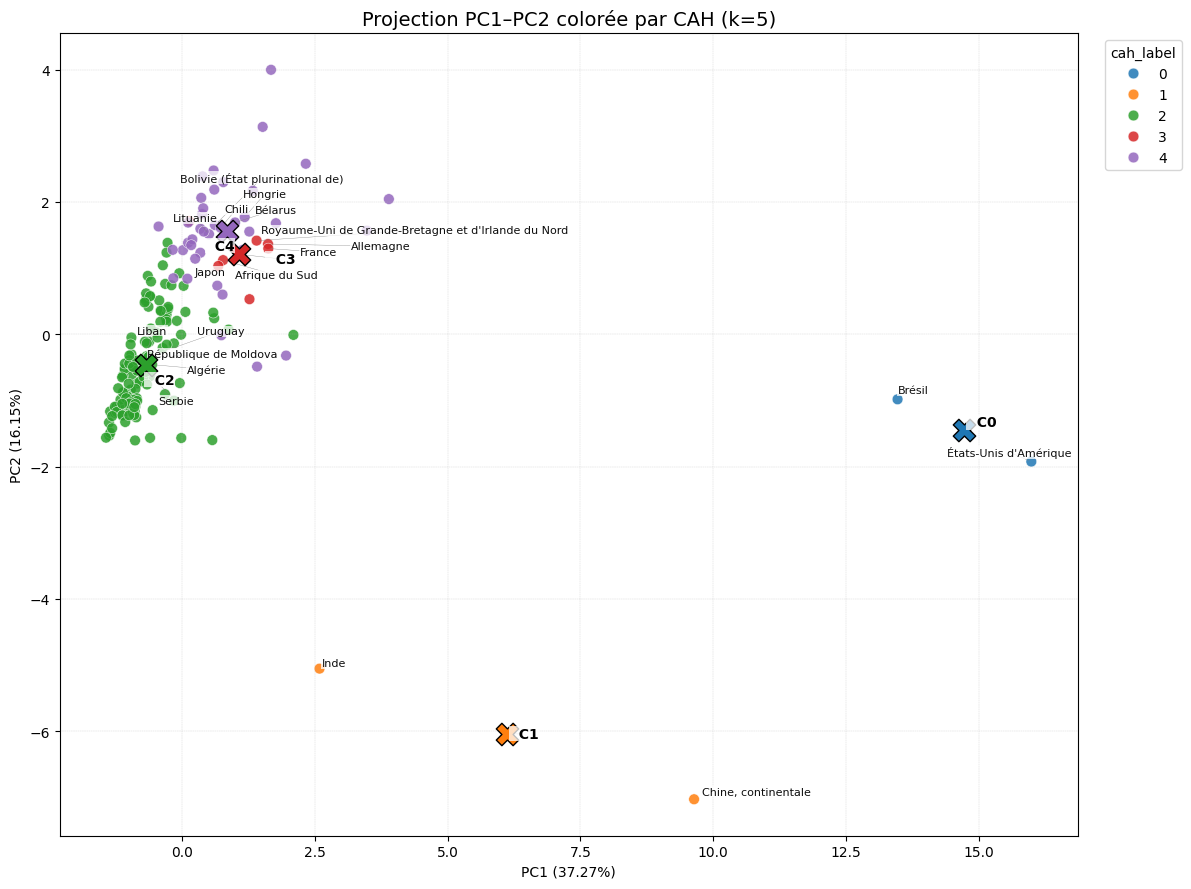

In [66]:
# Paramètres d'affichage
figsize = (12,9)
point_size = 60
alpha_point = 0.85
fontsz_label = 8
fontsz_centroid = 10
label_box = dict(facecolor='white', alpha=0.75, edgecolor='none', pad=0.4)

# Figure
plt.figure(figsize=figsize)
palette = sns.color_palette('tab10', n_colors=max(10, int(df_clusters['cah_label'].nunique())))
sns.scatterplot(x='PC1', y='PC2', hue='cah_label', data=df_clusters,
                palette=palette, s=point_size, alpha=alpha_point, edgecolor='w', linewidth=0.4)

# Centroides CAH (moyennes des PC pour chaque cah_label)
centroids = df_clusters.groupby('cah_label')[['PC1','PC2']].mean().reset_index()

centroid_texts = []
for _, row in centroids.iterrows():
    c = int(row['cah_label'])
    cx, cy = row['PC1'], row['PC2']
    plt.scatter(cx, cy, marker='X', s=260, color=[palette[c]], edgecolor='k', linewidth=1.0, zorder=5)
    t = plt.text(cx, cy, f'  C{c}', fontsize=fontsz_centroid, fontweight='bold', va='center',
                 bbox=label_box, zorder=6)
    centroid_texts.append(t)

# Annoter un sous-ensemble d'observations pour lisibilité (ex: top N par distance au centroïde par cluster)
N_per_cluster = 5
texts = []
for c in sorted(df_clusters['cah_label'].unique()):
    subset = df_clusters[df_clusters['cah_label'] == c].copy()
    if subset.empty:
        continue
    # distance au centroïde
    cx = centroids.loc[centroids['cah_label']==c, 'PC1'].values[0]
    cy = centroids.loc[centroids['cah_label']==c, 'PC2'].values[0]
    subset['dist_centroid'] = np.sqrt((subset['PC1'] - cx)**2 + (subset['PC2'] - cy)**2)
    top_idx = subset.nsmallest(n=min(N_per_cluster, len(subset)), columns='dist_centroid').index
    for idx in top_idx:
        x = subset.loc[idx, 'PC1']
        y = subset.loc[idx, 'PC2']
        name = subset.loc[idx, 'Zone'] if 'Zone' in subset.columns else str(idx)
        txt = plt.text(x, y, name, fontsize=fontsz_label, alpha=0.95,
                       bbox=label_box, zorder=4)
        texts.append(txt)

# Ajuster les textes pour réduire chevauchement
if texts or centroid_texts:
    adjust_text(texts + centroid_texts, only_move={'points':'y','texts':'y'},
                expand_text=(1.02,1.2), arrowprops=dict(arrowstyle='-', color='gray', lw=0.25))

# Axes, titre, légende
explained_var = getattr(pca, 'explained_variance_ratio_', None)
if explained_var is not None and len(explained_var) >= 2:
    xlabel = f'PC1 ({explained_var[0]:.2%})'
    ylabel = f'PC2 ({explained_var[1]:.2%})'
else:
    xlabel, ylabel = 'PC1', 'PC2'

plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(f'Projection PC1–PC2 colorée par CAH (k={int(df_clusters["cah_label"].nunique())})', fontsize=14)
plt.legend(title='cah_label', bbox_to_anchor=(1.02,1), loc='upper left', frameon=True)
plt.grid(True, linestyle='--', linewidth=0.3, alpha=0.6)
plt.tight_layout()
plt.show()


STATISTIQUES DESCRIPTIVES

In [67]:

sns.set(style='whitegrid', context='notebook')

# Paramètres
cluster_label_col = 'cah_label'   # colonne CAH
PC_cols = ['PC1','PC2']           # si présentes
MAX_BOXPLOT_VARS = 12

# Vérifier df_clusters et la colonne cah_label
if 'df_clusters' not in globals():
    raise RuntimeError("df_clusters introuvable. Exécutez la cellule qui construit df_clusters avant ce bloc.")
if cluster_label_col not in df_clusters.columns:
    raise KeyError(f"Colonne '{cluster_label_col}' introuvable dans df_clusters.")

# Détecter features numériques candidates (exclure index, Zone, PC1/PC2 et labels)
exclude = {cluster_label_col, '_orig_index', 'index', 'Zone'} | set(PC_cols)
feat_cols = [c for c in df_clusters.select_dtypes(include=[np.number]).columns if c not in exclude]

# Si aucune feature numérique détectée, lever une erreur explicite
if len(feat_cols) == 0:
    raise RuntimeError("Aucune colonne numérique détectée pour décrire les clusters. Définissez manuellement `feat_cols`.")

print("Nombre de features retenues :", len(feat_cols))
print("Extrait des features :", feat_cols[:40])

Nombre de features retenues : 11
Extrait des features : ['Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité intérieure', 'Importations - Quantité', 'Exportations - Quantité', 'Production', 'Population', 'Pib_par_habitant', 'Net_trade', 'Auto_sufficiency', 'Production_per_capita', 'kmeans_label']


In [68]:
# Nettoyage des features avant visualisation CAH
exclude_patterns = ['kmeans', 'cluster', 'label', 'cah', 'centroid', 'dist', 'score']  # adapter si besoin
exclude_exact = {'_orig_index', 'index', 'Zone', 'PC1', 'PC2'}

# construire feat_cols propre : toutes les colonnes numériques sauf celles à exclure
feat_cols_clean = []
for c in df_clusters.select_dtypes(include=[float, int]).columns:
    if c in exclude_exact:
        continue
    low = c.lower()
    if any(p in low for p in exclude_patterns):
        continue
    feat_cols_clean.append(c)

# Si la liste est vide, alerter et proposer fallback manuel
if not feat_cols_clean:
    raise RuntimeError("Aucune feature détectée après filtrage automatique. Définissez manuellement feat_cols_clean.")

print(f"{len(feat_cols_clean)} features retenues pour CAH (extrait) :", feat_cols_clean[:40])

# Remplacer feat_cols par feat_cols_clean pour la suite des blocs CAH
feat_cols = feat_cols_clean


10 features retenues pour CAH (extrait) : ['Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité intérieure', 'Importations - Quantité', 'Exportations - Quantité', 'Production', 'Population', 'Pib_par_habitant', 'Net_trade', 'Auto_sufficiency', 'Production_per_capita']


Effectifs par cluster :


,cah_label,n_obs
0,0,2
1,1,2
2,2,119
3,3,7
4,4,39


Centroïdes (moyennes) :


,Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Production,Population,Pib_par_habitant,Net_trade,Auto_sufficiency,Production_per_capita
cah_label,,,,,,,,,,
0,2.0417,6.1431,-0.1172,8.4075,6.9700,1.4493,1.1673,-8.2902,1.0911,2.9942
1,-0.8027,4.6744,0.8101,0.4107,4.0893,8.6838,-0.4253,-0.0893,0.4369,-0.4787
2,-0.2813,-0.2002,-0.2196,-0.2101,-0.2033,-0.1300,-0.3561,0.1198,-0.3155,-0.4765
3,0.5960,0.7142,3.9165,0.2762,0.4483,0.2346,0.8694,1.2118,0.0903,0.4253
4,0.6877,-0.0721,-0.0685,0.1391,-0.0272,-0.1652,0.8923,-0.1533,0.8680,1.2487


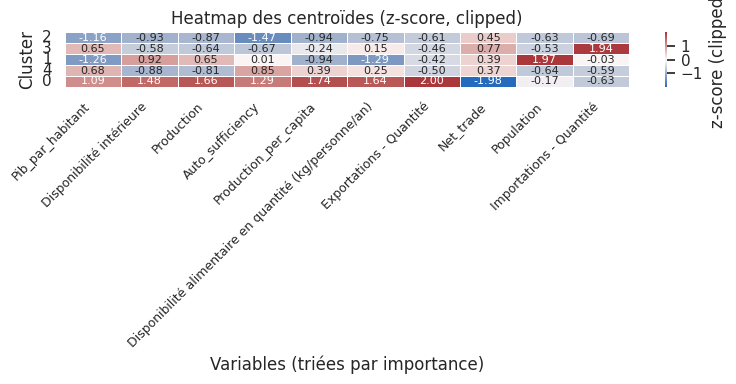

In [69]:
# 2. Centroides (moyennes) et heatmap lisible
# calculer moyennes, std et effectifs
centroids_df = df_clusters.groupby(cluster_label_col)[feat_cols].mean()
centroids_std = df_clusters.groupby(cluster_label_col)[feat_cols].std()
counts = df_clusters.groupby(cluster_label_col).size().rename('n_obs')

print("Effectifs par cluster :")
display(counts.reset_index())

print("Centroïdes (moyennes) :")
display(centroids_df.round(4))

# Heatmap z-score avec clipping et tri des variables par importance
cent_z = (centroids_df - centroids_df.mean()) / centroids_df.std(ddof=0)
cent_z = cent_z.clip(-3, 3)  # limiter extrêmes pour lisibilité

# trier variables par amplitude moyenne absolue sur centroïdes
var_order = cent_z.abs().mean(axis=0).sort_values(ascending=False).index.tolist()
cent_z = cent_z[var_order]

# trier clusters par première composante SVD pour ordre visuel
try:
    u, s, vt = np.linalg.svd(cent_z.fillna(0).values, full_matrices=False)
    cluster_order = cent_z.index[np.argsort(u[:,0])[::-1]]
    cent_z = cent_z.loc[cluster_order]
except Exception:
    pass

plt.figure(figsize=(max(8, 0.35 * cent_z.shape[1]), max(4, 0.6 * cent_z.shape[0])))
sns.heatmap(cent_z, cmap='vlag', center=0, annot=True, fmt='.2f',
            annot_kws={'fontsize':8}, linewidths=0.4, cbar_kws={'label':'z-score (clipped)'})
plt.title("Heatmap des centroïdes (z-score, clipped)")
plt.xlabel("Variables (triées par importance)"); plt.ylabel("Cluster")
plt.xticks(rotation=45, ha='right', fontsize=9); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()


/tmp/ipython-input-2957268196.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




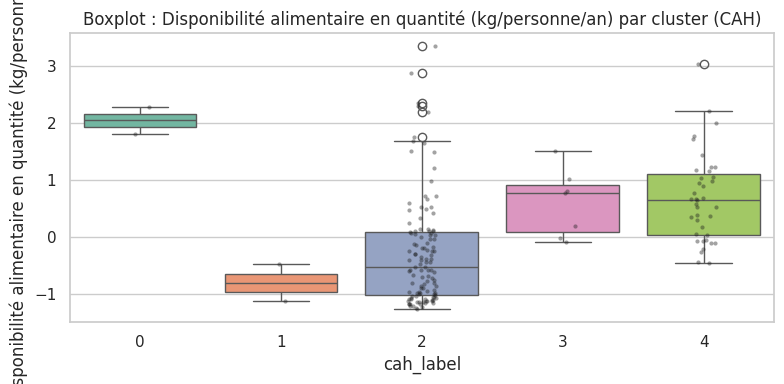

/tmp/ipython-input-2957268196.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




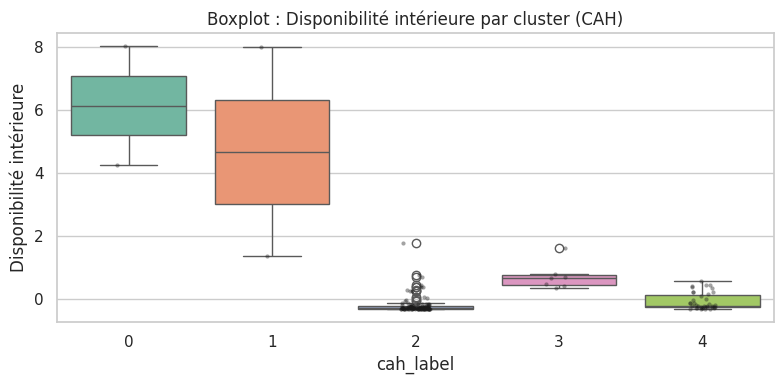

/tmp/ipython-input-2957268196.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




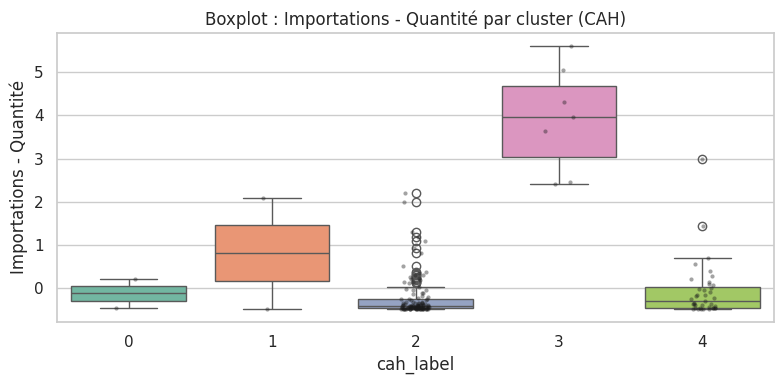

/tmp/ipython-input-2957268196.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




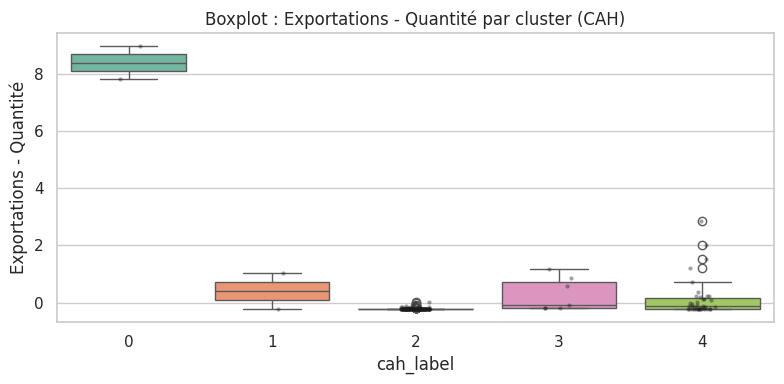

/tmp/ipython-input-2957268196.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




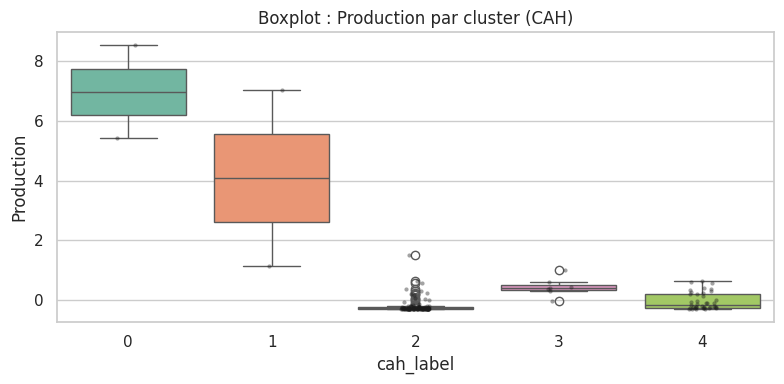

/tmp/ipython-input-2957268196.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




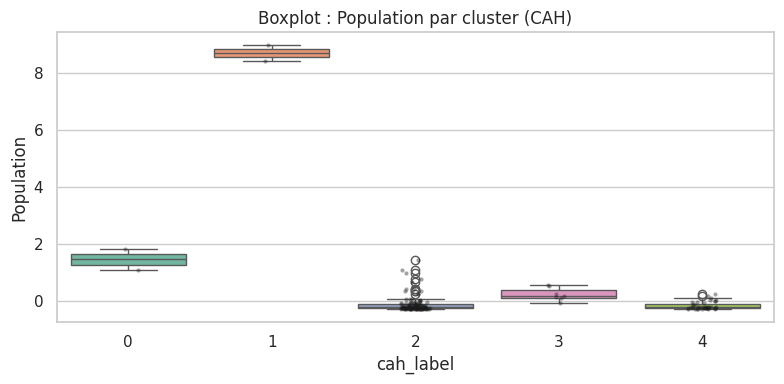

/tmp/ipython-input-2957268196.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




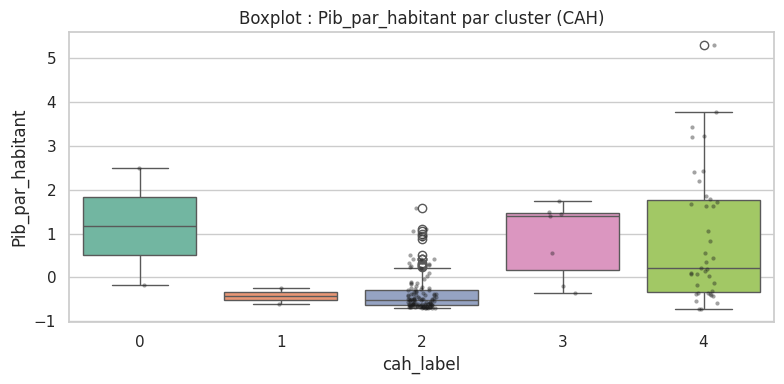

/tmp/ipython-input-2957268196.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




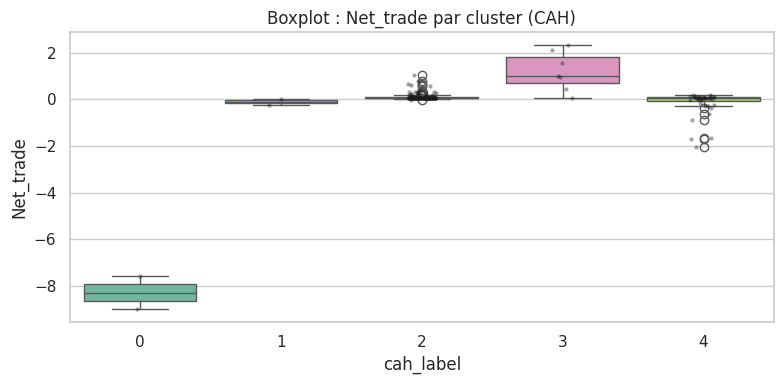

/tmp/ipython-input-2957268196.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




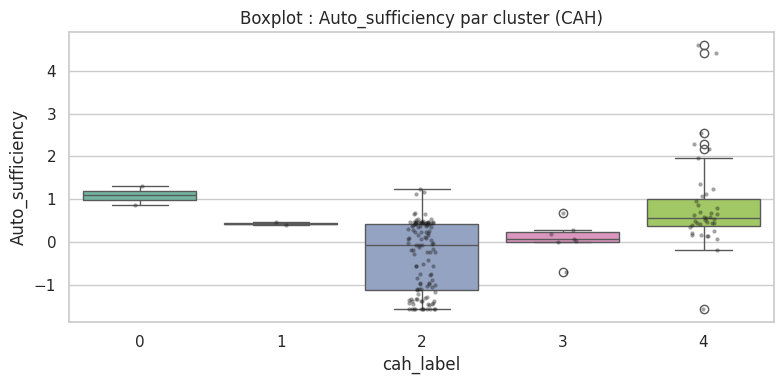

/tmp/ipython-input-2957268196.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




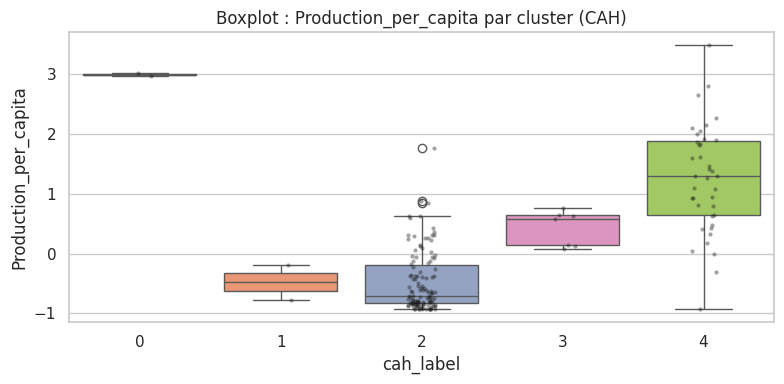

/tmp/ipython-input-2957268196.py:23: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



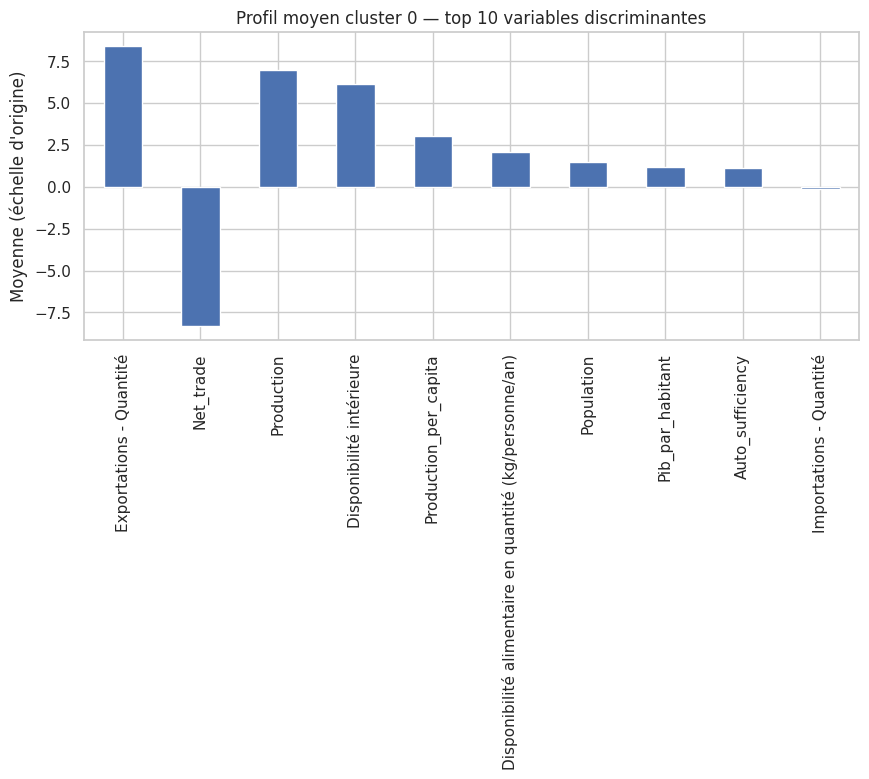

/tmp/ipython-input-2957268196.py:23: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



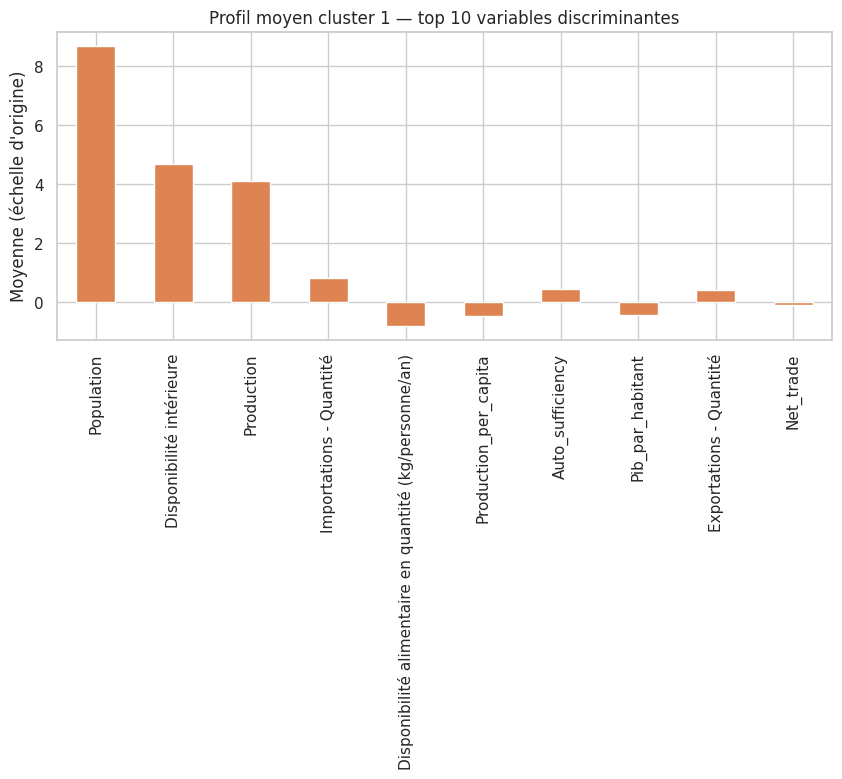

/tmp/ipython-input-2957268196.py:23: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



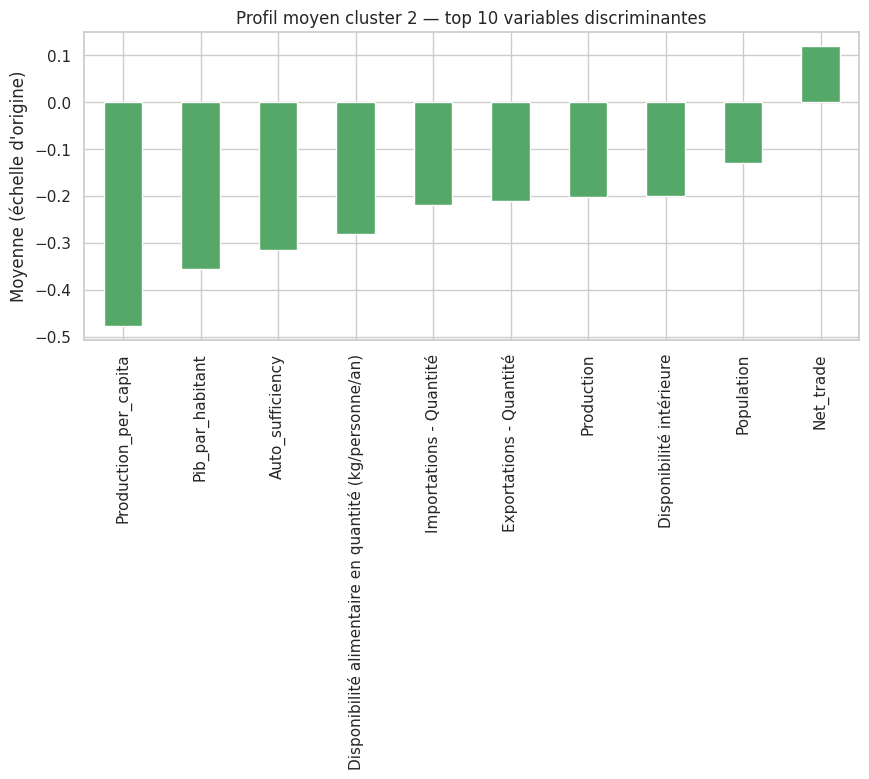

/tmp/ipython-input-2957268196.py:23: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



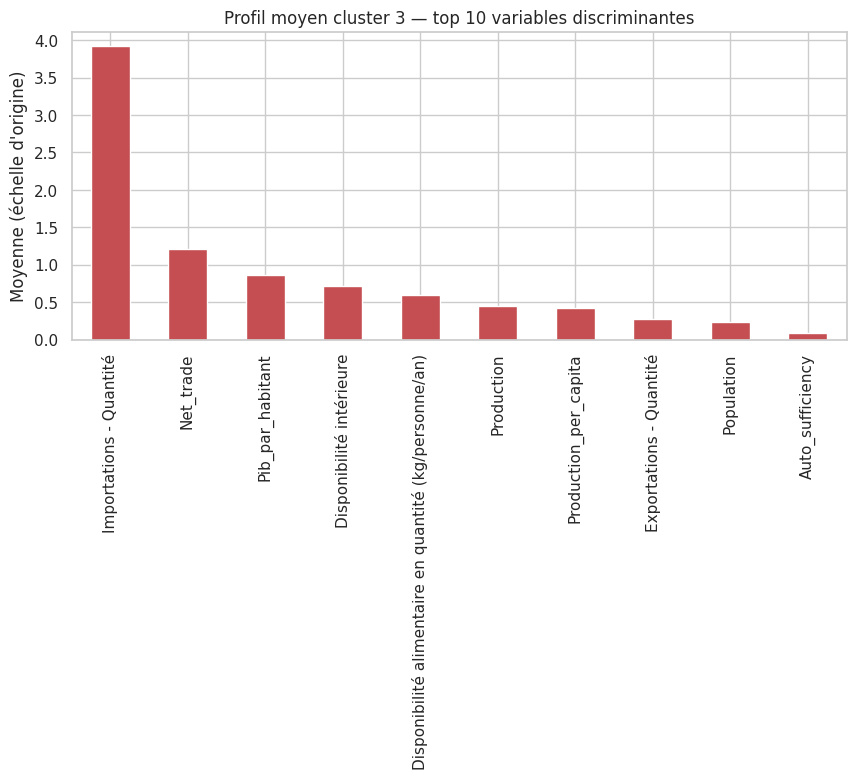

/tmp/ipython-input-2957268196.py:23: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



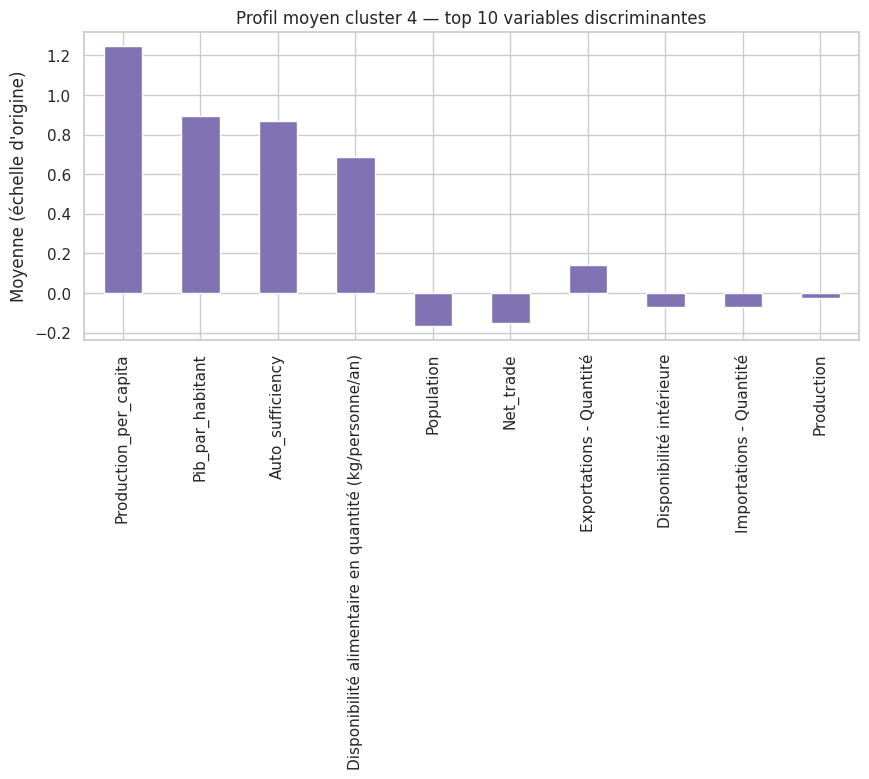

Variables discriminantes (top 10) par cluster :
  cluster 0 : ['Exportations - Quantité', 'Net_trade', 'Production', 'Disponibilité intérieure', 'Production_per_capita', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Population', 'Pib_par_habitant', 'Auto_sufficiency', 'Importations - Quantité']
  cluster 1 : ['Population', 'Disponibilité intérieure', 'Production', 'Importations - Quantité', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Production_per_capita', 'Auto_sufficiency', 'Pib_par_habitant', 'Exportations - Quantité', 'Net_trade']
  cluster 2 : ['Production_per_capita', 'Pib_par_habitant', 'Auto_sufficiency', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Importations - Quantité', 'Exportations - Quantité', 'Production', 'Disponibilité intérieure', 'Population', 'Net_trade']
  cluster 3 : ['Importations - Quantité', 'Net_trade', 'Pib_par_habitant', 'Disponibilité intérieure', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Product

In [70]:
# 3. Boxplots (limiter le nombre de variables pour lisibilité)
vars_to_plot = feat_cols if len(feat_cols) <= MAX_BOXPLOT_VARS else feat_cols[:MAX_BOXPLOT_VARS]

for v in vars_to_plot:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=cluster_label_col, y=v, data=df_clusters, palette='Set2')
    sns.stripplot(x=cluster_label_col, y=v, data=df_clusters, color='k', size=3, alpha=0.4, jitter=True)
    plt.title(f"Boxplot : {v} par cluster (CAH)")
    plt.tight_layout(); plt.show()

# 4. Profils moyens et variables discriminantes
global_mean = df_clusters[feat_cols].mean()
discriminants = {}
for cl in sorted(df_clusters[cluster_label_col].unique()):
    cent = centroids_df.loc[cl]
    diff = (cent - global_mean).abs().sort_values(ascending=False)
    top_vars = diff.index[:10].tolist()
    discriminants[cl] = top_vars
    plt.figure(figsize=(10,4))
    cent.loc[top_vars].plot(kind='bar', color=f'C{int(cl) % 10}')
    plt.title(f"Profil moyen cluster {cl} — top {len(top_vars)} variables discriminantes")
    plt.ylabel("Moyenne (échelle d'origine)")
    plt.tight_layout(); plt.show()

print("Variables discriminantes (top 10) par cluster :")
for cl, vars_ in discriminants.items():
    print(f"  cluster {cl} : {vars_}")


In [71]:
# 5. Générer une description textuelle synthétique pour chaque cluster
def describe_cluster(cluster_id, centroids_df, centroids_std, counts, global_mean, top_n=5):
    mean_vals = centroids_df.loc[cluster_id]
    std_vals = centroids_std.loc[cluster_id] if cluster_id in centroids_std.index else pd.Series(np.nan, index=centroids_df.columns)
    n = int(counts.loc[cluster_id]) if cluster_id in counts.index else 0

    # variables les plus élevées et les plus faibles (relativement à la moyenne globale)
    rel = (mean_vals - global_mean)
    top_high = rel.sort_values(ascending=False).head(top_n).index.tolist()
    top_low = rel.sort_values(ascending=True).head(top_n).index.tolist()

    # construire texte
    lines = []
    lines.append(f"Cluster {cluster_id} — n = {n} observations ({n/len(df_clusters)*100:.1f}%)")
    lines.append("Profil synthétique :")
    # phrase sur variables élevées
    if top_high:
        vals = ', '.join([f"{v} (moy={mean_vals[v]:.2f})" for v in top_high])
        lines.append(f"  • Variables nettement supérieures à la moyenne : {vals}.")
    # phrase sur variables faibles
    if top_low:
        vals = ', '.join([f"{v} (moy={mean_vals[v]:.2f})" for v in top_low])
        lines.append(f"  • Variables nettement inférieures à la moyenne : {vals}.")
    # dispersion
    high_var = std_vals.sort_values(ascending=False).head(3).index.tolist()
    if high_var:
        lines.append(f"  • Variables avec forte dispersion intra-cluster : {', '.join(high_var)}.")
    return "\n".join(lines)

print("\nDescriptions automatiques par cluster (CAH) :\n")
for cl in sorted(centroids_df.index):
    desc = describe_cluster(cl, centroids_df, centroids_std, counts, global_mean, top_n=4)
    print(desc)
    print("-" * 80)



Descriptions automatiques par cluster (CAH) :

Cluster 0 — n = 2 observations (1.2%)
Profil synthétique :
  • Variables nettement supérieures à la moyenne : Exportations - Quantité (moy=8.41), Production (moy=6.97), Disponibilité intérieure (moy=6.14), Production_per_capita (moy=2.99).
  • Variables nettement inférieures à la moyenne : Net_trade (moy=-8.29), Importations - Quantité (moy=-0.12), Auto_sufficiency (moy=1.09), Pib_par_habitant (moy=1.17).
  • Variables avec forte dispersion intra-cluster : Disponibilité intérieure, Production, Pib_par_habitant.
--------------------------------------------------------------------------------
Cluster 1 — n = 2 observations (1.2%)
Profil synthétique :
  • Variables nettement supérieures à la moyenne : Population (moy=8.68), Disponibilité intérieure (moy=4.67), Production (moy=4.09), Importations - Quantité (moy=0.81).
  • Variables nettement inférieures à la moyenne : Disponibilité alimentaire en quantité (kg/personne/an) (moy=-0.80), Produc

In [72]:
# affichage lisible
for c in sorted(df_clusters['cah_label'].unique()):
    names = df_clusters.loc[df_clusters['cah_label'] == c, 'Zone'].astype(str).tolist()
    print(f"CAH Cluster {c} (n={len(names)}):")
    for i in range(0, len(names), 10):
        print("  " + ", ".join(names[i:i+10]))
    print('-'*80)


CAH Cluster 0 (n=2):
  Brésil, États-Unis d'Amérique
--------------------------------------------------------------------------------
CAH Cluster 1 (n=2):
  Chine, continentale, Inde
--------------------------------------------------------------------------------
CAH Cluster 2 (n=119):
  Afghanistan, Albanie, Algérie, Angola, Antigua-et-Barbuda, Arménie, Azerbaïdjan, Bahamas, Bangladesh, Bosnie-Herzégovine
  Botswana, Bulgarie, Burkina Faso, Bénin, Cabo Verde, Cambodge, Cameroun, Chypre, Congo, Costa Rica
  Croatie, Cuba, Côte d'Ivoire, Djibouti, Dominique, El Salvador, Estonie, Eswatini, Fidji, Fédération de Russie
  Gabon, Gambie, Ghana, Grenade, Grèce, Guatemala, Guinée, Guinée-Bissau, Géorgie, Haïti
  Honduras, Indonésie, Iran (République islamique d'), Iraq, Jordanie, Kazakhstan, Kenya, Kirghizistan, Kiribati, Koweït
  Lesotho, Lettonie, Liban, Libéria, Macédoine du Nord, Madagascar, Malawi, Maldives, Mali, Malte
  Maroc, Mauritanie, Mongolie, Monténégro, Mozambique, Myanmar, Nami

## CROISER K-MEANS ET CAH

In [73]:
# Précondition : df_clusters contient bien les colonnes 'kmeans_label' et 'cah_label'
assert 'kmeans_label' in df_clusters.columns, "kmeans_label absent"
assert 'cah_label' in df_clusters.columns, "cah_label absent"

# Si cah_label est 1..k (fcluster), on peut normaliser en 0..k-1 (optionnel)
# df_clusters['cah_label'] = df_clusters['cah_label'] - 1

In [74]:
# table de contingence (pivot) : counts KMeans vs CAH
contingency = pd.crosstab(df_clusters['kmeans_label'], df_clusters['cah_label'])
print(contingency)


cah_label     0  1    2  3   4
kmeans_label                  
0             0  2    0  0   0
1             0  0  107  0   0
2             0  0   11  0  39
3             2  0    0  0   0
4             0  0    1  7   0


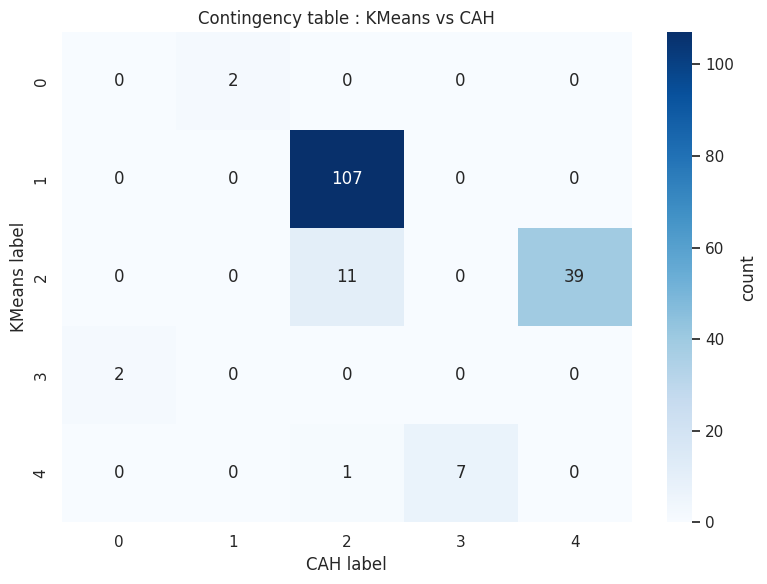

In [75]:
plt.figure(figsize=(8,6))
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', cbar_kws={'label':'count'})
plt.xlabel('CAH label')
plt.ylabel('KMeans label')
plt.title('Contingency table : KMeans vs CAH')
plt.tight_layout()
plt.show()


In [76]:
# Vérifications interprétation + conclusion

In [77]:
# Examiner tailles et purities (pourcentage dominant) — pour valider interprétation

contingency = pd.crosstab(df_clusters['kmeans_label'], df_clusters['cah_label'])
summary = pd.concat([
    contingency.sum(axis=1).rename('k_size'),
    contingency.max(axis=1).rename('dominant_count')
], axis=1)
summary['dominant_pct'] = (summary['dominant_count']/summary['k_size']).round(3)
print(summary)


              k_size  dominant_count  dominant_pct
kmeans_label                                      
0                  2               2         1.000
1                107             107         1.000
2                 50              39         0.780
3                  2               2         1.000
4                  8               7         0.875


<Axes: xlabel='PC1', ylabel='PC2'>

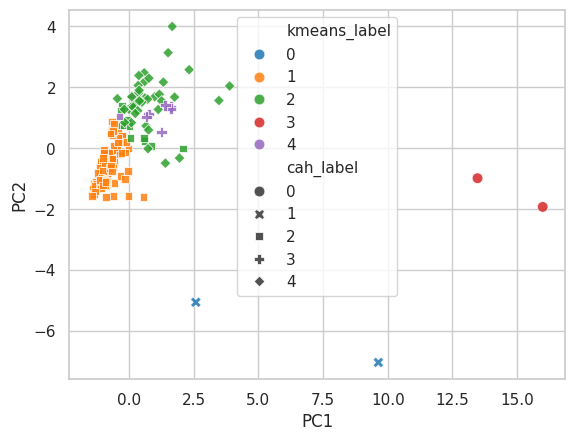

In [78]:
# Visualiser la correspondance sur PC1–PC2 (forme=CAH, couleur=KMeans) pour repérer zones de chevauchement :
sns.scatterplot(x='PC1', y='PC2', hue='kmeans_label', style='cah_label',
                data=df_clusters, palette='tab10', s=60, alpha=0.85)


In [79]:
# Regarder moyennes des features pour clusters impliqués (p.ex. K3 split) — identifier variables qui expliquent la séparation

features = ['Disponibilité alimentaire en quantité (kg/personne/an)', 'Production', 'Importations - Quantité', 'Population', 'Pib_par_habitant']  # adaptez
print("K3 mean:", df_clusters[df_clusters['kmeans_label']==3][features].mean().round(3))
print("CAH2 mean:", df_clusters[df_clusters['cah_label']==2][features].mean().round(3))
print("CAH4 mean:", df_clusters[df_clusters['cah_label']==4][features].mean().round(3))


K3 mean: Disponibilité alimentaire en quantité (kg/personne/an)    2.042
Production                                                6.970
Importations - Quantité                                  -0.117
Population                                                1.449
Pib_par_habitant                                          1.167
dtype: float64
CAH2 mean: Disponibilité alimentaire en quantité (kg/personne/an)   -0.281
Production                                               -0.203
Importations - Quantité                                  -0.220
Population                                               -0.130
Pib_par_habitant                                         -0.356
dtype: float64
CAH4 mean: Disponibilité alimentaire en quantité (kg/personne/an)    0.688
Production                                               -0.027
Importations - Quantité                                  -0.068
Population                                               -0.165
Pib_par_habitant                           

In [80]:
# Colonnes attendues (adapter si vos noms diffèrent)
kmeans_label_col = 'kmeans_label'
cah_label_col = 'cah_label'

# Colonnes cibles à créer si nécessaires
km_sil_col = 'sil_kmeans_sample'
cah_sil_col = 'sil_cah_sample'

# Vérifications rapides
for lbl in (kmeans_label_col, cah_label_col):
    if lbl not in df_clusters.columns:
        raise KeyError(f"Colonne de label manquante: {lbl}")

# Fonction utilitaire pour calculer et attacher silhouette_samples si manquant
def ensure_silhouette(df, X_array, label_col, sil_col):
    if sil_col in df.columns:
        return None  # déjà présent
    labels = df[label_col].values
    unique = np.unique(labels)
    if len(unique) < 2:
        df[sil_col] = np.nan
        return None
    # encoder labels en entiers contigus si nécessaire
    mapping = {lab: i for i, lab in enumerate(unique)}
    int_labels = np.array([mapping[l] for l in labels])
    df[sil_col] = silhouette_samples(X_array, int_labels)
    return silhouette_score(X_array, int_labels)

# Préparer X utilisé pour silhouette (mêmes features et même ordre que df_clusters)
# Hypothèse: X_for_clustering existe et a le même index/order que df_clusters
if 'X_for_clustering' not in globals():
    raise RuntimeError("Variable X_for_clustering introuvable. Elle doit contenir les features standardisés utilisés pour le clustering.")

# aligner index/order si nécessaire
if not all(X_for_clustering.index == df_clusters.index):
    X = X_for_clustering.reindex(df_clusters.index).values
else:
    X = X_for_clustering.values

# Calcul (si nécessaire) et récupération des scores globaux
global_km = ensure_silhouette(df_clusters, X, kmeans_label_col, km_sil_col)
global_cah = ensure_silhouette(df_clusters, X, cah_label_col, cah_sil_col)

# Afficher scores globaux (si calculés)
if global_km is not None:
    print("Silhouette global KMeans:", global_km)
if global_cah is not None:
    print("Silhouette global CAH:", global_cah)

# Afficher moyennes par cluster (colonnes créées ou existantes)
print("\nMoyenne silhouette par cluster (KMeans) — colonne utilisée:", km_sil_col)
print(df_clusters.groupby(kmeans_label_col)[km_sil_col].mean().sort_index())

print("\nMoyenne silhouette par cluster (CAH) — colonne utilisée:", cah_sil_col)
print(df_clusters.groupby(cah_label_col)[cah_sil_col].mean().sort_index())


Silhouette global KMeans: 0.30505528421040073
Silhouette global CAH: 0.3204324591413332

Moyenne silhouette par cluster (KMeans) — colonne utilisée: sil_kmeans_sample
kmeans_label
0    0.139541
1    0.391672
2    0.115363
3    0.561030
4    0.309523
Name: sil_kmeans_sample, dtype: float64

Moyenne silhouette par cluster (CAH) — colonne utilisée: sil_cah_sample
cah_label
0    0.560273
1    0.135927
2    0.379850
3    0.394017
4    0.123088
Name: sil_cah_sample, dtype: float64
